# Comprehensive Dataset Analysis - NYSE Market

This notebook provides a thorough analysis of the NYSE temporal graph dataset following the thesis structure.

## Analysis Structure:
1. **Cross-Dataset Comparison**
   - Feature Distribution Comparison
   - Class Balance Analysis
   - Comparison of Degree Distribution
   - Connectivity Comparison
2. **Feature Analysis**
3. **Graph Topology Analysis**
   - Homophily
   - Authorities and Hubs
   - Centrality
4. **Temporal Analysis of the Graph**
   - Temporal Evolution of the Topology

## Setup and Data Loading

In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import entropy

# Add the project root to the Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from dataset_analyzer import MarketAnalyzer

# Set plot style for thesis-quality figures
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
FIGURE_OUTPUT_PATH = Path('./thesis_figures/NYSE')
FIGURE_OUTPUT_PATH.mkdir(exist_ok=True, parents=True)

def save_figure(filename):
    """Helper function to save figures in a consistent format."""
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.pdf", format='pdf', bbox_inches='tight')
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.png", format='png', bbox_inches='tight', dpi=300)
    print(f"Figure saved to {FIGURE_OUTPUT_PATH / f'{filename}.pdf'}")

In [ ]:
# Configuration
MARKET = 'NYSE'
NORMALIZATION = 'zscore'
WINDOW_SIZE = 22
adj_minmax = False
threshold = .1

# Define dataset paths
base_path = project_root / 'data' / 'datasets' / 'graph'
train_path = base_path / f"{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}"
val_path = base_path / f"{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}"
test_path = base_path / f"{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}"

# Load datasets
train_analyzer = MarketAnalyzer(train_path, adj_minmax=adj_minmax, threshold=threshold)
val_analyzer = MarketAnalyzer(val_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)
test_analyzer = MarketAnalyzer(test_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)

analyzers = {'Train': train_analyzer, 'Validation': val_analyzer, 'Test': test_analyzer}

print("Datasets loaded successfully.")

# Dataset Overview
overview_data = []
for name, analyzer in analyzers.items():
    info = {
        'Dataset': name,
        'Num Nodes': analyzer.num_nodes,
        'Num Features': analyzer.num_features,
        'Num Snapshots': analyzer.num_snapshots
    }
    overview_data.append(info)

overview_df = pd.DataFrame(overview_data).set_index('Dataset')
print("\n--- Dataset Overview ---")
display(overview_df)

|             Dataset Information             |
| Market Name:         NYSE                    |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         22                      |
| Normalizer:          zscore                  |
| Number of Features:  5                       |
| Number of Nodes:     1171                    |
| Number of Snapshots: 219                     |
Folder analysis_results already exists at /extra/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/NYSE_Train_2016-05-01_2017-06-30_22_zscore
|             Dataset Information             |
| Market Name:         NYSE                    |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         22                      |
| Normalizer:          zscore                  |
| Number of Feature

,Num Nodes,Num Features,Num Snapshots
Dataset,,,
Train,1171,5,219
Validation,1171,5,101
Test,1171,5,456


In [3]:
# Centralize adjacency matrices for all splits (optimization)
train_adjs = train_analyzer.get_snapshots_adjacency_matrix()

Adjacency matrix shape: (1171, 1171)


In [4]:
val_adjs = val_analyzer.get_snapshots_adjacency_matrix()


Adjacency matrix shape: (1171, 1171)


In [5]:
test_adjs = test_analyzer.get_snapshots_adjacency_matrix()


Adjacency matrix shape: (1171, 1171)


In [6]:
adjacency_matrices = {'Train': train_adjs, 'Validation': val_adjs, 'Test': test_adjs}
print("Adjacency matrices loaded.")

Adjacency matrices loaded.


## Comprehensive Analysis Functions

Define reusable functions for computing comprehensive metrics across all datasets.

In [7]:
def compute_comprehensive_graph_metrics(analyzer, adjacency_matrices, subsample_snapshots=None):
    """
    Compute comprehensive graph topology metrics for directed graphs.
    
    Args:
        analyzer: MarketAnalyzer instance
        adjacency_matrices: List of adjacency matrices
        subsample_snapshots: If specified, randomly sample this many snapshots
    
    Returns:
        Dictionary with mean and std for each metric
    """
    num_snapshots = analyzer.num_snapshots
    
    if subsample_snapshots is not None and subsample_snapshots < num_snapshots:
        snapshot_indices = np.random.choice(num_snapshots, size=subsample_snapshots, replace=False)
        print(f"  → Subsampling {subsample_snapshots} snapshots out of {num_snapshots}")
    else:
        snapshot_indices = range(num_snapshots)
    
    # Initialize metric storage
    metrics_data = {
        'connectivity': [],
        'sparsity': [],
        'num_weakly_cc': [],
        'num_strongly_cc': [],
        'reciprocity': [],
        'clustering': [],
        'homophily': [],
        'avg_in_degree': [],
        'avg_out_degree': [],
        'density': []
    }
    
    for idx, i in enumerate(snapshot_indices):
        if idx % 10 == 0:
            print(f"  → Processing snapshot {idx+1}/{len(snapshot_indices)}...", end='\r')
        
        snapshot_info = analyzer.get_snapshot_info(i)
        num_nodes = snapshot_info['num_nodes']
        num_edges = snapshot_info['num_edges']
        
        # Basic metrics
        metrics_data['connectivity'].append(snapshot_info['connectivity'])
        possible_edges = num_nodes * (num_nodes - 1)
        sparsity = 1.0 - (num_edges / possible_edges) if possible_edges > 0 else 0.0
        metrics_data['sparsity'].append(sparsity)
        metrics_data['density'].append(num_edges / possible_edges if possible_edges > 0 else 0.0)
        
        # Homophily
        homophily = analyzer.get_homophily_score(i)
        metrics_data['homophily'].append(homophily)
        
        # Create directed graph
        from scipy.sparse import csr_matrix
        adj = adjacency_matrices[i]
        adj_sparse = csr_matrix(adj)
        G_directed = nx.from_scipy_sparse_array(adj_sparse, create_using=nx.DiGraph)
        
        # Directed-specific metrics
        metrics_data['num_weakly_cc'].append(nx.number_weakly_connected_components(G_directed))
        metrics_data['num_strongly_cc'].append(nx.number_strongly_connected_components(G_directed))
        
        # Reciprocity
        try:
            metrics_data['reciprocity'].append(nx.reciprocity(G_directed))
        except:
            metrics_data['reciprocity'].append(0.0)
        
        # Clustering coefficient
        try:
            metrics_data['clustering'].append(nx.average_clustering(G_directed))
        except:
            metrics_data['clustering'].append(0.0)
        
        # Average degrees
        in_degrees = dict(G_directed.in_degree())
        out_degrees = dict(G_directed.out_degree())
        metrics_data['avg_in_degree'].append(np.mean(list(in_degrees.values())))
        metrics_data['avg_out_degree'].append(np.mean(list(out_degrees.values())))
    
    print()
    
    # Compute statistics
    metrics_summary = {}
    for metric_name, values in metrics_data.items():
        metrics_summary[metric_name] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values)
        }
    
    return metrics_summary


def generate_latex_metrics_table(metrics_dict, market_name):
    """
    Generate a comprehensive LaTeX table for graph topology metrics.
    
    Args:
        metrics_dict: Dictionary with keys 'Train', 'Validation', 'Test'
        market_name: Name of the market (e.g., 'NASDAQ')
    
    Returns:
        LaTeX table string
    """
    dataset_order = ['Train', 'Validation', 'Test']
    available_datasets = [d for d in dataset_order if d in metrics_dict]
    
    # Define metric display names and order
    metric_display = {
        'connectivity': 'Connectivity',
        'sparsity': 'Sparsity',
        'density': 'Density',
        'homophily': 'Homophily',
        'reciprocity': 'Reciprocity',
        'clustering': 'Clustering Coefficient',
        'avg_in_degree': 'Avg In-Degree',
        'avg_out_degree': 'Avg Out-Degree',
        'num_weakly_cc': 'Weakly CC',
        'num_strongly_cc': 'Strongly CC'
    }
    
    latex = []
    latex.append(r"\begin{table}[H]")
    latex.append(r"    \centering")
    latex.append(r"    \small")
    
    # Column specification
    col_spec = "l|" + "c" * len(available_datasets)
    latex.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    latex.append(r"        \toprule")
    
    # Header row
    header = r"        \textbf{Metric}"
    for dataset in available_datasets:
        header += f" & \\textbf{{{dataset}}}"
    header += r" \\"
    latex.append(header)
    latex.append(r"        \midrule")
    
    # Data rows
    for metric_key, metric_name in metric_display.items():
        if metric_key not in metrics_dict[available_datasets[0]]:
            continue
        
        row = f"        {metric_name:30s}"
        
        for dataset in available_datasets:
            mean_val = metrics_dict[dataset][metric_key]['mean']
            std_val = metrics_dict[dataset][metric_key]['std']
            
            if 'cc' in metric_key.lower():
                row += f" & ${mean_val:.1f} \\pm {std_val:.2f}$"
            elif 'degree' in metric_key.lower():
                row += f" & ${mean_val:.2f} \\pm {std_val:.2f}$"
            else:
                row += f" & ${mean_val:.3f} \\pm {std_val:.3f}$"
        
        row += r" \\"
        latex.append(row)
    
    latex.append(r"        \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(f"    \\caption{{Comprehensive Graph Topology Metrics for {market_name} Dataset (Mean $\\pm$ Std)}}")
    latex.append(f"    \\label{{tab:{market_name.lower()}_topology_metrics}}")
    latex.append(r"\end{table}")
    
    return "\n".join(latex)

## Compute Comprehensive Metrics

This section computes comprehensive graph topology metrics across all datasets.

In [8]:
# Compute comprehensive metrics for all datasets
SUBSAMPLE_SNAPSHOTS = 5  # Use 20 snapshots for comprehensive analysis

print(f"Computing comprehensive metrics for {MARKET}...")
print(f"Settings: subsample={SUBSAMPLE_SNAPSHOTS}\n")

comprehensive_metrics = {}
for name, analyzer in analyzers.items():
    adj_mats = adjacency_matrices.get(name)
    if adj_mats is None or len(adj_mats) == 0:
        print(f"⚠ Skipping {name}: no adjacency matrices available")
        continue
    
    print(f"Processing {name}... ({analyzer.num_snapshots} snapshots)")
    metrics = compute_comprehensive_graph_metrics(
        analyzer, 
        adj_mats,
        subsample_snapshots=SUBSAMPLE_SNAPSHOTS
    )
    comprehensive_metrics[name] = metrics

print("\n✓ Metrics computation complete!")

Computing comprehensive metrics for NYSE...
Settings: subsample=5

Processing Train... (219 snapshots)
  → Subsampling 5 snapshots out of 219



Processing Validation... (101 snapshots)
  → Subsampling 5 snapshots out of 101
  → Processing snapshot 1/5...
Processing Test... (456 snapshots)
  → Subsampling 5 snapshots out of 456
  → Processing snapshot 1/5...

✓ Metrics computation complete!


In [9]:
# Display comprehensive metrics summary
summary_data = []
for name, metrics in comprehensive_metrics.items():
    for metric_name, values in metrics.items():
        summary_data.append({
            'Dataset': name,
            'Metric': metric_name,
            'Mean': values['mean'],
            'Std': values['std'],
            'Min': values['min'],
            'Max': values['max']
        })

summary_df = pd.DataFrame(summary_data)
summary_pivot = summary_df.pivot(index='Metric', columns='Dataset', values='Mean')

print("\n" + "="*80)
print(f"COMPREHENSIVE GRAPH TOPOLOGY METRICS - {MARKET}")
print("="*80)
display(summary_pivot.round(4))

# Generate and save LaTeX table
latex_table = generate_latex_metrics_table(comprehensive_metrics, MARKET)

print("\n" + "="*80)
print("LATEX TABLE CODE")
print("="*80)
print(latex_table)
print("="*80)

# Save to file
latex_output_path = FIGURE_OUTPUT_PATH / f"{MARKET}_topology_metrics_table.tex"
with open(latex_output_path, 'w') as f:
    f.write(latex_table)
print(f"\n✓ LaTeX table saved to: {latex_output_path}")


COMPREHENSIVE GRAPH TOPOLOGY METRICS - NYSE


Dataset,Test,Train,Validation
Metric,,,
avg_in_degree,605.6280,605.2485,605.0109
avg_out_degree,605.6280,605.2485,605.0109
clustering,0.5181,0.5175,0.5174
connectivity,0.5176,0.5173,0.5171
density,0.5176,0.5173,0.5171
homophily,0.5589,0.5273,0.5507
num_strongly_cc,29.0000,27.8000,33.0000
num_weakly_cc,1.0000,1.0000,1.0000
reciprocity,0.0705,0.0679,0.0675



LATEX TABLE CODE
\begin{table}[H]
    \centering
    \small
    \begin{tabular}{l|ccc}
        \toprule
        \textbf{Metric} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\
        \midrule
        Connectivity                   & $0.517 \pm 0.003$ & $0.517 \pm 0.001$ & $0.518 \pm 0.001$ \\
        Sparsity                       & $0.483 \pm 0.003$ & $0.483 \pm 0.001$ & $0.482 \pm 0.001$ \\
        Density                        & $0.517 \pm 0.003$ & $0.517 \pm 0.001$ & $0.518 \pm 0.001$ \\
        Homophily                      & $0.527 \pm 0.032$ & $0.551 \pm 0.076$ & $0.559 \pm 0.061$ \\
        Reciprocity                    & $0.068 \pm 0.008$ & $0.068 \pm 0.002$ & $0.070 \pm 0.003$ \\
        Clustering Coefficient         & $0.518 \pm 0.003$ & $0.517 \pm 0.001$ & $0.518 \pm 0.001$ \\
        Avg In-Degree                  & $605.25 \pm 2.99$ & $605.01 \pm 0.88$ & $605.63 \pm 1.26$ \\
        Avg Out-Degree                 & $605.25 \pm 2.99$ & $605.01 \pm 0.88$ & $

Figure saved to thesis_figures/NYSE/comprehensive_metrics_comparison.pdf


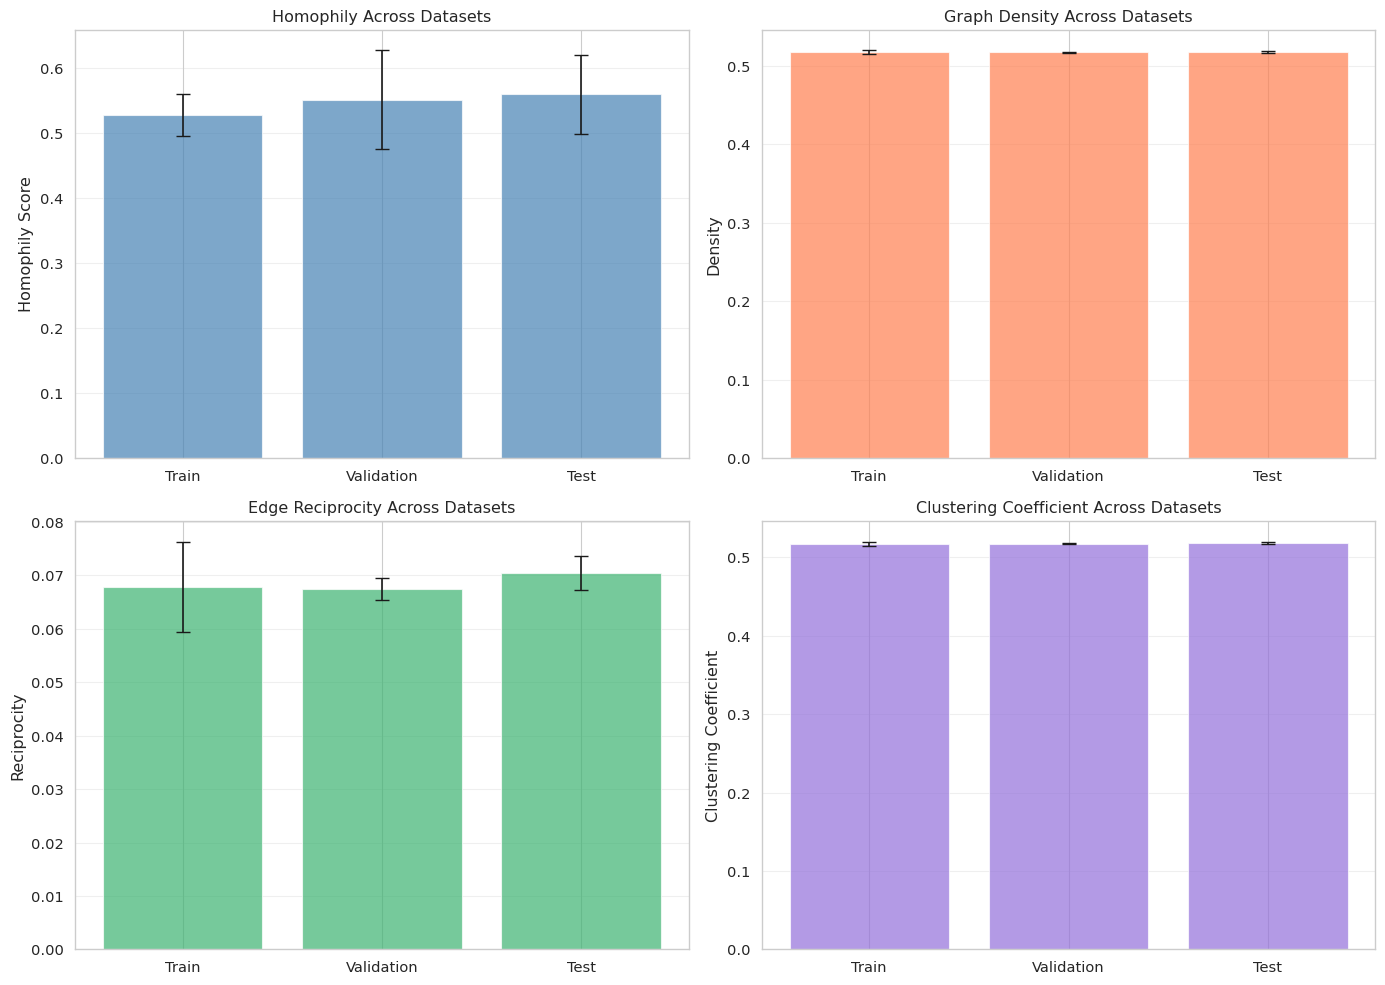

In [10]:
# Visualize key metrics comparison across datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metric 1: Homophily
ax = axes[0, 0]
homophily_data = {name: metrics['homophily']['mean'] for name, metrics in comprehensive_metrics.items()}
homophily_std = {name: metrics['homophily']['std'] for name, metrics in comprehensive_metrics.items()}
x_pos = np.arange(len(homophily_data))
ax.bar(x_pos, homophily_data.values(), yerr=homophily_std.values(), capsize=5, alpha=0.7, color='steelblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(homophily_data.keys())
ax.set_ylabel('Homophily Score')
ax.set_title('Homophily Across Datasets')
ax.grid(axis='y', alpha=0.3)

# Metric 2: Density
ax = axes[0, 1]
density_data = {name: metrics['density']['mean'] for name, metrics in comprehensive_metrics.items()}
density_std = {name: metrics['density']['std'] for name, metrics in comprehensive_metrics.items()}
ax.bar(x_pos, density_data.values(), yerr=density_std.values(), capsize=5, alpha=0.7, color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(density_data.keys())
ax.set_ylabel('Density')
ax.set_title('Graph Density Across Datasets')
ax.grid(axis='y', alpha=0.3)

# Metric 3: Reciprocity
ax = axes[1, 0]
reciprocity_data = {name: metrics['reciprocity']['mean'] for name, metrics in comprehensive_metrics.items()}
reciprocity_std = {name: metrics['reciprocity']['std'] for name, metrics in comprehensive_metrics.items()}
ax.bar(x_pos, reciprocity_data.values(), yerr=reciprocity_std.values(), capsize=5, alpha=0.7, color='mediumseagreen')
ax.set_xticks(x_pos)
ax.set_xticklabels(reciprocity_data.keys())
ax.set_ylabel('Reciprocity')
ax.set_title('Edge Reciprocity Across Datasets')
ax.grid(axis='y', alpha=0.3)

# Metric 4: Clustering Coefficient
ax = axes[1, 1]
clustering_data = {name: metrics['clustering']['mean'] for name, metrics in comprehensive_metrics.items()}
clustering_std = {name: metrics['clustering']['std'] for name, metrics in comprehensive_metrics.items()}
ax.bar(x_pos, clustering_data.values(), yerr=clustering_std.values(), capsize=5, alpha=0.7, color='mediumpurple')
ax.set_xticks(x_pos)
ax.set_xticklabels(clustering_data.keys())
ax.set_ylabel('Clustering Coefficient')
ax.set_title('Clustering Coefficient Across Datasets')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_figure('comprehensive_metrics_comparison')
plt.show()

### Interpretation Guide for Graph Topology Metrics

**Key Metrics and Their Interpretation:**

1. **Homophily** (0 to 1, higher is better for GNNs):
   - Measures tendency of nodes with same label (Up/Down) to connect
   - High values (>0.6): Neighbor information is highly predictive → favorable for standard GNNs
   - Low values (<0.4): Heterophilic graph → may need specialized architectures
   - **Expected**: Financial markets often show moderate homophily due to sector correlations

2. **Density** (0 to 1):
   - Proportion of actual edges vs. possible edges
   - Low density (<0.1): Sparse graph → efficient computation, locality matters
   - High density (>0.5): Dense graph → global information propagates quickly
   - **Expected**: Stock markets typically sparse (0.05-0.15) due to selective correlations

3. **Reciprocity** (0 to 1):
   - Fraction of edges with a reverse edge (A→B and B→A)
   - High reciprocity: Mutual influence between stocks (e.g., same sector)
   - Low reciprocity: Asymmetric relationships (e.g., leader-follower dynamics)
   - **Expected**: Moderate reciprocity (0.3-0.6) indicates mixed relationship types

4. **Clustering Coefficient** (0 to 1):
   - Tendency to form triangles (transitive relationships)
   - High clustering: Strong community structure (e.g., sectors/industries)
   - Low clustering: More hub-and-spoke patterns
   - **Expected**: Moderate clustering (0.2-0.5) due to sector groupings

5. **Connectivity**:
   - Average edge density across snapshots
   - Stability indicates consistent market structure
   - High variance suggests volatile relationship patterns

6. **Connected Components**:
   - **Weakly CC**: Nodes connected ignoring edge direction → overall market segmentation
   - **Strongly CC**: Nodes connected respecting direction → core influence groups
   - Single large WCC: Integrated market
   - Multiple SCCs: Hierarchical influence structure

7. **Average Degree**:
   - Number of connections per node
   - In-degree: How many stocks influence this one (information sink)
   - Out-degree: How many stocks this one influences (information source)
   - **Expected**: Power-law distribution with few high-degree hubs

**Cross-Dataset Consistency:**
- Train/Val/Test should have similar metric values
- Large discrepancies indicate distributional shift → model may not generalize well
- Temporal stability (low std) suggests robust graph structure

---
## 1. Cross-Dataset Comparison

### 1.1. Feature Distribution Comparison

Figure saved to thesis_figures/NYSE/cross_dataset_feature_distribution_all.pdf


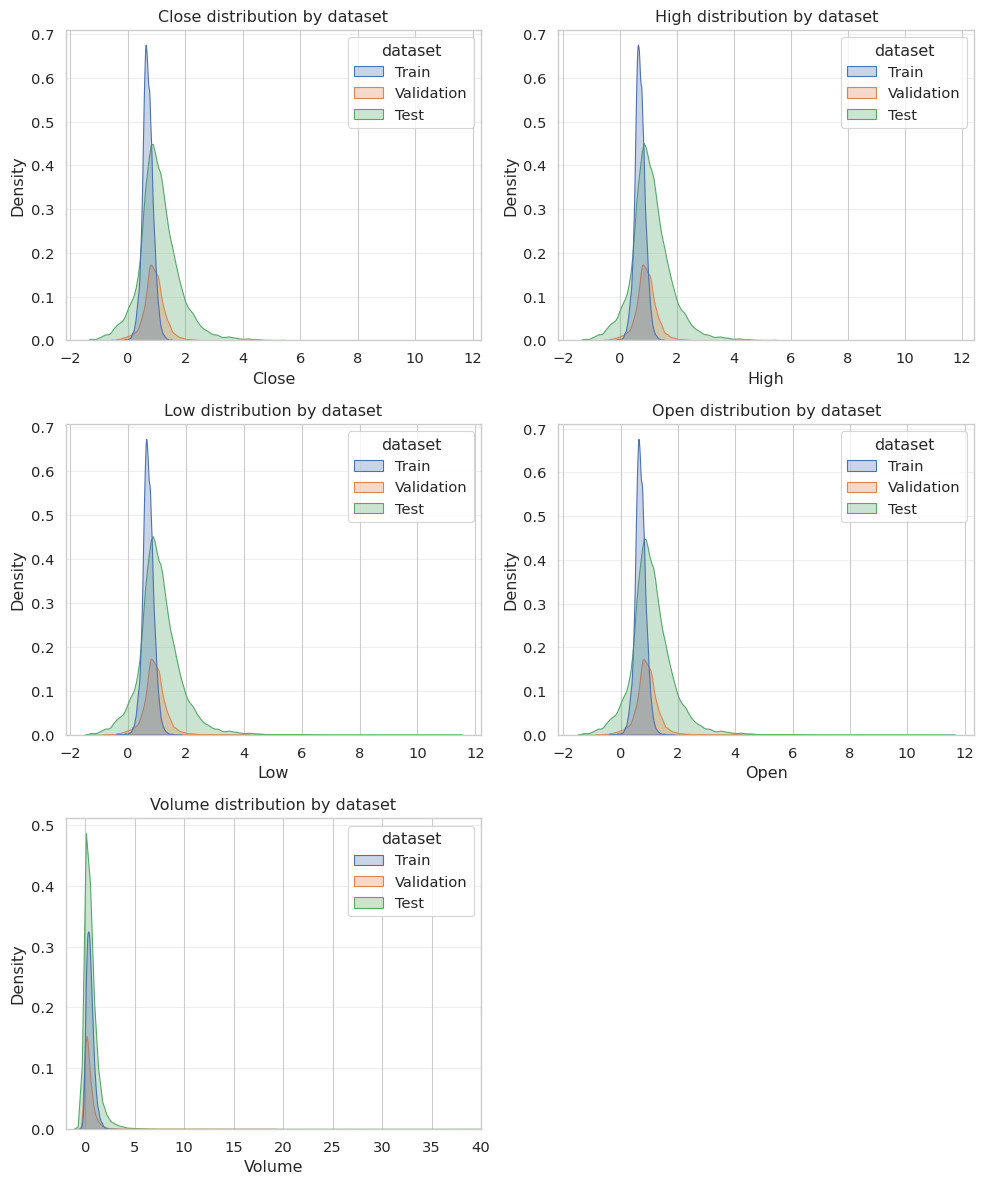

In [11]:
# Build combined features dataframe
feature_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    df['dataset'] = name
    feature_data.append(df)

full_feature_df = pd.concat(feature_data, ignore_index=True)

#Remove every data on PYS ticker
full_feature_df = full_feature_df[~(full_feature_df['ticker'] == 'PYS')]


# Select numeric features to plot
candidate_features = ['Close', 'High', 'Low', 'Open', 'Volume']
numeric_features = [f for f in candidate_features if f in full_feature_df.columns and pd.api.types.is_numeric_dtype(full_feature_df[f])]

n = len(numeric_features)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

for idx, feature in enumerate(numeric_features):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]
    tmp = full_feature_df[[feature, 'dataset']].dropna()
    if tmp[feature].nunique() <= 1:
        ax.text(0.5, 0.5, f'{feature}: constant', ha='center', va='center')
        ax.set_axis_off()
        continue
    if feature == 'Volume':
        sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
        ax.set_xlim(-2, 40)
    else:
        sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
    ax.set_title(f'{feature} distribution by dataset')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.grid(True, axis='y', alpha=0.3)

# Turn off leftover axes
total_axes = nrows * ncols
for j in range(n, total_axes):
    r, c = divmod(j, ncols)
    axes[r][c].set_axis_off()

plt.tight_layout()
save_figure('cross_dataset_feature_distribution_all')
plt.show()

In [12]:
# Feature Means and Variances by Dataset
all_numeric_features = [f for f in getattr(train_analyzer, 'features', []) if f in full_feature_df.columns and pd.api.types.is_numeric_dtype(full_feature_df[f])]

if len(all_numeric_features) > 0:
    stats_df = full_feature_df.groupby('dataset')[all_numeric_features].agg(['mean', 'var'])
    desired_order = [name for name in ['Train', 'Validation', 'Test'] if name in stats_df.index]
    if desired_order:
        stats_df = stats_df.loc[desired_order]
    stats_df_rounded = stats_df.round(4)
    print('--- Feature Means and Variances by Dataset ---')
    display(stats_df_rounded)
else:
    print('No numeric features found to summarize.')

--- Feature Means and Variances by Dataset ---


Close            High             Low            Open          \
              mean     var    mean     var    mean     var    mean     var   
dataset                                                                      
Train       0.6838  0.0367  0.6838  0.0364  0.6840  0.0369  0.6840  0.0367   
Validation  0.9065  0.1563  0.9049  0.1556  0.9083  0.1566  0.9065  0.1562   
Test        1.0869  0.6019  1.0899  0.6031  1.0856  0.6015  1.0883  0.6031   

            Volume          
              mean     var  
dataset                     
Train       0.4420  0.1450  
Validation  0.3702  0.3670  
Test        0.5523  1.1055

In [13]:
# Generate LaTeX table for Feature Means and Variances
if len(all_numeric_features) > 0:
    print("\n" + "=" * 90)
    print("LATEX TABLE - Feature Means and Variances")
    print("=" * 90)
    
    latex_lines = []
    latex_lines.append(r"\begin{table}[H]")
    latex_lines.append(r"    \centering")
    latex_lines.append(r"    \small")
    
    # Create column specification (Feature | Mean (Train/Val/Test) | Variance (Train/Val/Test))
    latex_lines.append(r"    \begin{tabular}{l|ccc|ccc}")
    latex_lines.append(r"        \toprule")
    latex_lines.append(r"        \textbf{Feature} & \multicolumn{3}{c|}{\textbf{Mean}} & \multicolumn{3}{c}{\textbf{Variance}} \\")
    latex_lines.append(r"        & \textbf{Train} & \textbf{Val} & \textbf{Test} & \textbf{Train} & \textbf{Val} & \textbf{Test} \\")
    latex_lines.append(r"        \midrule")
    
    # Add data rows
    for feature in all_numeric_features:
        row = f"        {feature:15s}"
        
        # Mean values
        for dataset in ['Train', 'Validation', 'Test']:
            if dataset in stats_df.index:
                mean_val = stats_df.loc[dataset, (feature, 'mean')]
                row += f" & {mean_val:.3f}"
            else:
                row += " & --"
        
        # Variance values
        for dataset in ['Train', 'Validation', 'Test']:
            if dataset in stats_df.index:
                var_val = stats_df.loc[dataset, (feature, 'var')]
                row += f" & {var_val:.3f}"
            else:
                row += " & --"
        
        row += r" \\"
        latex_lines.append(row)
    
    latex_lines.append(r"        \bottomrule")
    latex_lines.append(r"    \end{tabular}")
    latex_lines.append(r"    \caption{Feature Means and Variances Across NYSE Datasets}")
    latex_lines.append(r"    \label{tab:nyse_feature_stats}")
    latex_lines.append(r"\end{table}")
    
    latex_table = "\n".join(latex_lines)
    print(latex_table)
    
    # Save to file
    with open('nyse_feature_stats.tex', 'w') as f:
        f.write(latex_table)
    print("\n✓ LaTeX table saved to: nyse_feature_stats.tex")
else:
    print("No numeric features available for LaTeX table generation.")


LATEX TABLE - Feature Means and Variances
\begin{table}[H]
    \centering
    \small
    \begin{tabular}{l|ccc|ccc}
        \toprule
        \textbf{Feature} & \multicolumn{3}{c|}{\textbf{Mean}} & \multicolumn{3}{c}{\textbf{Variance}} \\
        & \textbf{Train} & \textbf{Val} & \textbf{Test} & \textbf{Train} & \textbf{Val} & \textbf{Test} \\
        \midrule
        Close           & 0.684 & 0.906 & 1.087 & 0.037 & 0.156 & 0.602 \\
        High            & 0.684 & 0.905 & 1.090 & 0.036 & 0.156 & 0.603 \\
        Low             & 0.684 & 0.908 & 1.086 & 0.037 & 0.157 & 0.602 \\
        Open            & 0.684 & 0.906 & 1.088 & 0.037 & 0.156 & 0.603 \\
        Volume          & 0.442 & 0.370 & 0.552 & 0.145 & 0.367 & 1.105 \\
        \bottomrule
    \end{tabular}
    \caption{Feature Means and Variances Across NYSE Datasets}
    \label{tab:nyse_feature_stats}
\end{table}

✓ LaTeX table saved to: nyse_feature_stats.tex


### 1.2. Class Balance Analysis

Figure saved to thesis_figures/NYSE/cross_dataset_class_distribution.pdf


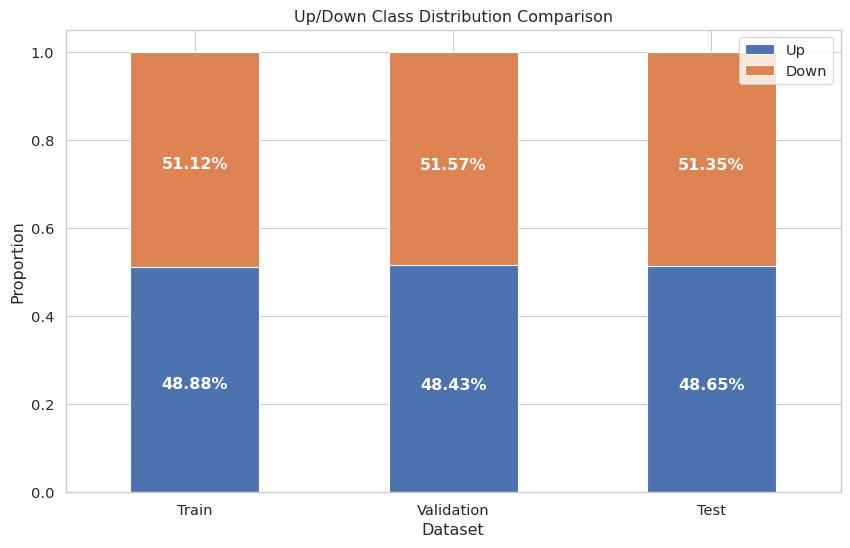

In [14]:
# Compare Up/Down Class Distribution
class_ratios = {name: analyzer.get_class_dist() for name, analyzer in analyzers.items()}
class_df = pd.DataFrame(class_ratios).T.rename(columns={0: 'Down', 1: 'Up'})

class_df.plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)
plt.title('Up/Down Class Distribution Comparison')
plt.ylabel('Proportion')
plt.xlabel('Dataset')
for index, row in enumerate(class_df.itertuples()):
    if row.Down > 0:
        plt.text(index, row.Down / 2, f'{row.Down:.2%}', ha='center', va='center', color='white', weight='bold')
    if row.Up > 0:
        plt.text(index, row.Down + (row.Up / 2), f'{row.Up:.2%}', ha='center', va='center', color='white', weight='bold')
save_figure('cross_dataset_class_distribution')
plt.show()

### 1.3. Comparison of Degree Distribution

Figure saved to thesis_figures/NYSE/cross_dataset_degree_distribution.pdf


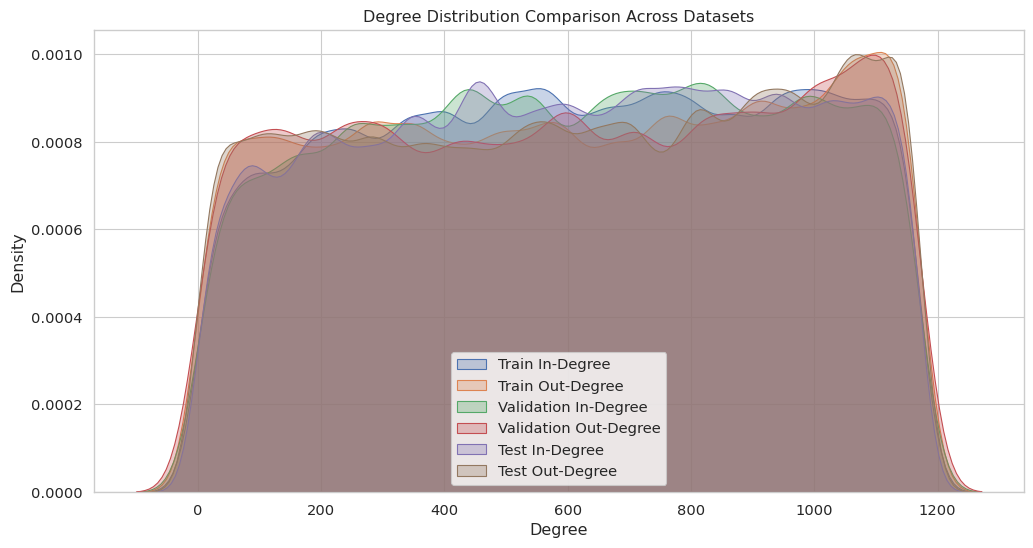

In [15]:
# Degree Distribution Comparison
plt.figure(figsize=(12, 6))
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, label=f'{name} In-Degree', fill=True, alpha=0.3)
    sns.kdeplot(out_degrees, label=f'{name} Out-Degree', fill=True, alpha=0.3)
plt.title('Degree Distribution Comparison Across Datasets')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
save_figure('cross_dataset_degree_distribution')
plt.show()

Figure saved to thesis_figures/NYSE/unweighted_degree_distribution.pdf


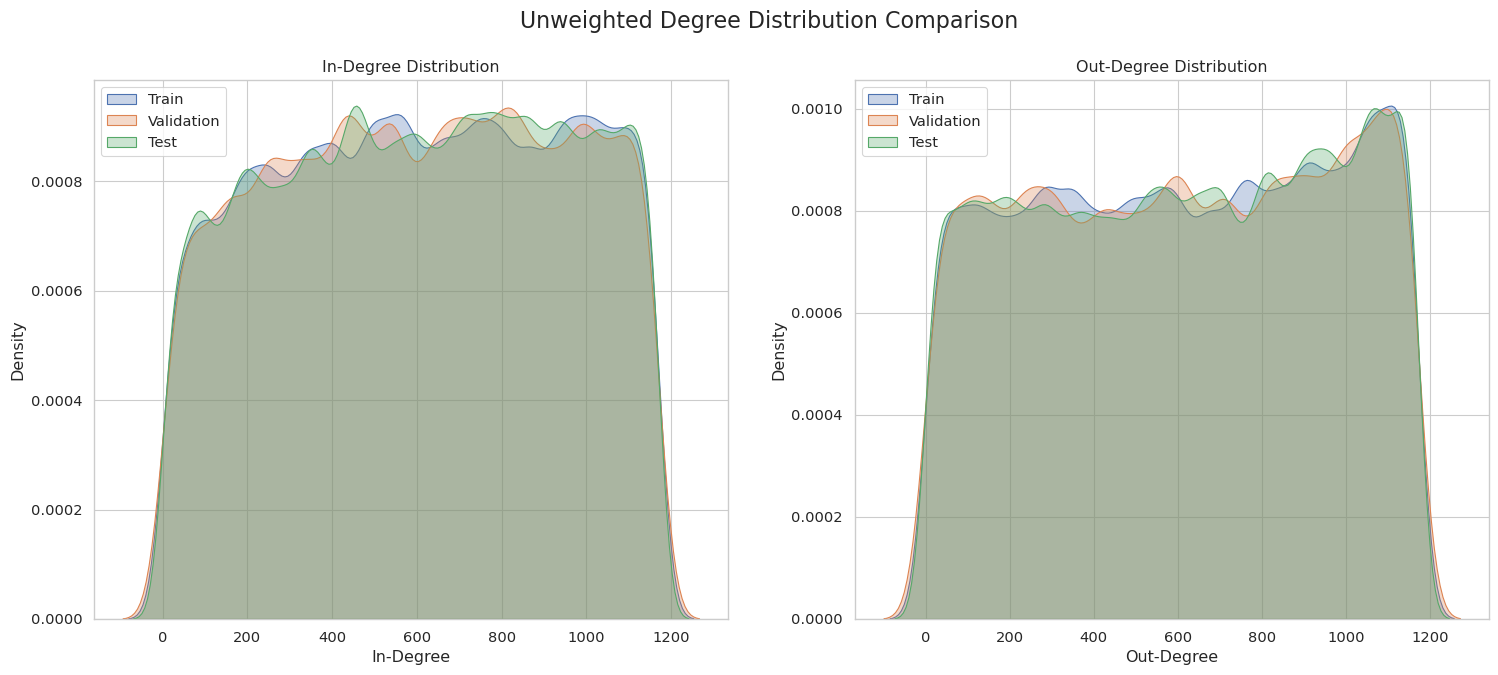

Figure saved to thesis_figures/NYSE/weighted_degree_distribution.pdf


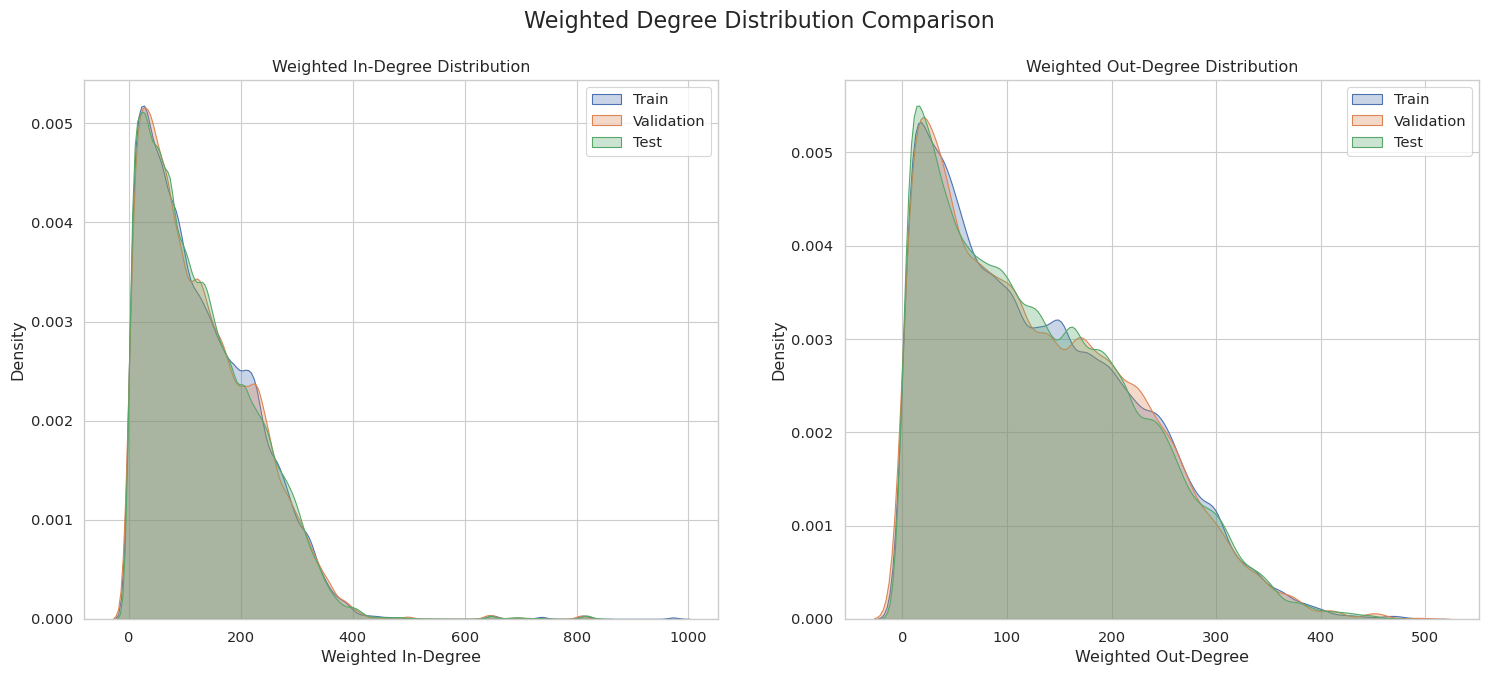

In [16]:
# --- Unweighted (Absolute) Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Unweighted Degree Distribution Comparison', fontsize=16)

# In-Degree
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('In-Degree Distribution')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Out-Degree
for name, analyzer in analyzers.items():
    _, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Out-Degree Distribution')
axes[1].set_xlabel('Out-Degree')
axes[1].legend()

save_figure('unweighted_degree_distribution')
plt.show()

# --- Weighted Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Weighted Degree Distribution Comparison', fontsize=16)

# Weighted In-Degree
for name, analyzer in analyzers.items():
    _, _, weighted_in_degrees, _ = analyzer.get_degree_dist()
    sns.kdeplot(weighted_in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('Weighted In-Degree Distribution')
axes[0].set_xlabel('Weighted In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Weighted Out-Degree
for name, analyzer in analyzers.items():
    _, _, _, weighted_out_degrees = analyzer.get_degree_dist()
    sns.kdeplot(weighted_out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Weighted Out-Degree Distribution')
axes[1].set_xlabel('Weighted Out-Degree')
axes[1].legend()

save_figure('weighted_degree_distribution')
plt.show()


Sampled 20 random snapshots: [55, 90, 65, 83, 7]...
Figure saved to thesis_figures/NYSE/edge_weight_distribution_multi_snapshot.pdf


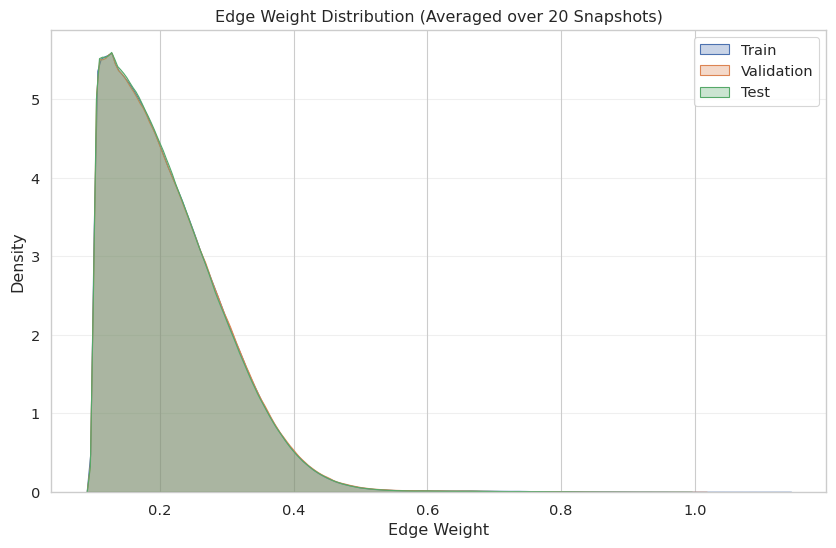


EDGE WEIGHT STATISTICS (Across Multiple Snapshots)

Train Dataset:
  Mean:     0.2129
  Std:      0.0869
  Variance: 0.0076
  Min:      0.1000
  Max:      1.1345
  Count:    14,202,766 edges

Validation Dataset:
  Mean:     0.2129
  Std:      0.0857
  Variance: 0.0073
  Min:      0.1000
  Max:      1.0085
  Count:    14,162,572 edges

Test Dataset:
  Mean:     0.2121
  Std:      0.0852
  Variance: 0.0073
  Min:      0.1000
  Max:      0.9862
  Count:    14,208,547 edges

LATEX TABLE - Edge Weight Statistics (Copy-Paste Ready)
\begin{table}[H]
    \centering
    \small
    \begin{tabular}{l|ccc}
        \toprule
        \textbf{Statistic} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\
        \midrule
        Mean            & 0.2129 & 0.2129 & 0.2121 \\
        Std Dev         & 0.0869 & 0.0857 & 0.0852 \\
        Variance        & 0.0076 & 0.0073 & 0.0073 \\
        Min             & 0.1000 & 0.1000 & 0.1000 \\
        Max             & 1.1345 & 1.0085 & 0.9862 \\
        

In [17]:
# Edge Weight Distribution Analysis (using multiple snapshots for better accuracy)
import random

# Sample multiple snapshots for more accurate statistics
NUM_SNAPSHOTS_EDGE_WEIGHTS = 20
available_lengths = [len(adjs) for adjs in [train_adjs, val_adjs, test_adjs] if adjs is not None]
if not available_lengths:
    raise ValueError('No adjacency matrices available to sample from.')

min_length = min(available_lengths)
snapshot_indices = random.sample(range(min_length), min(NUM_SNAPSHOTS_EDGE_WEIGHTS, min_length))
print(f"Sampled {len(snapshot_indices)} random snapshots: {snapshot_indices[:5]}..." if len(snapshot_indices) > 5 else snapshot_indices)

# Collect edge weights from multiple snapshots
edge_weights_data = {
    'Train': [],
    'Validation': [],
    'Test': []
}

edge_weights_sets = {
    'Train': train_adjs,
    'Validation': val_adjs,
    'Test': test_adjs
}

# Collect weights from all sampled snapshots
for snapshot_idx in snapshot_indices:
    for label, adjs in edge_weights_sets.items():
        if adjs is None or snapshot_idx >= len(adjs):
            continue
        weights = adjs[snapshot_idx][adjs[snapshot_idx] > 0].flatten()
        if len(weights) > 0:
            edge_weights_data[label].extend(weights.tolist())

# Plot combined distribution
plt.figure(figsize=(10, 6))
for label, weights in edge_weights_data.items():
    if len(weights) > 0:
        sns.kdeplot(weights, label=label, fill=True, alpha=0.3)

plt.legend()
plt.title(f'Edge Weight Distribution (Averaged over {len(snapshot_indices)} Snapshots)')
plt.xlabel('Edge Weight')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
save_figure('edge_weight_distribution_multi_snapshot')
plt.show()

# Compute statistics
edge_weight_stats = {}
for label, weights in edge_weights_data.items():
    if len(weights) > 0:
        edge_weight_stats[label] = {
            'mean': np.mean(weights),
            'std': np.std(weights),
            'var': np.var(weights),
            'min': np.min(weights),
            'max': np.max(weights),
            'count': len(weights)
        }

# Display statistics
print("\n" + "=" * 80)
print("EDGE WEIGHT STATISTICS (Across Multiple Snapshots)")
print("=" * 80)
for label, stats in edge_weight_stats.items():
    print(f"\n{label} Dataset:")
    print(f"  Mean:     {stats['mean']:.4f}")
    print(f"  Std:      {stats['std']:.4f}")
    print(f"  Variance: {stats['var']:.4f}")
    print(f"  Min:      {stats['min']:.4f}")
    print(f"  Max:      {stats['max']:.4f}")
    print(f"  Count:    {stats['count']:,} edges")

# Generate LaTeX table
print("\n" + "=" * 80)
print("LATEX TABLE - Edge Weight Statistics (Copy-Paste Ready)")
print("=" * 80)

latex_lines = []
latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"    \centering")
latex_lines.append(r"    \small")
latex_lines.append(r"    \begin{tabular}{l|ccc}")
latex_lines.append(r"        \toprule")
latex_lines.append(r"        \textbf{Statistic} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\")
latex_lines.append(r"        \midrule")

# Add rows for each statistic
metrics = [('Mean', 'mean'), ('Std Dev', 'std'), ('Variance', 'var'), 
           ('Min', 'min'), ('Max', 'max')]

for metric_name, metric_key in metrics:
    row = f"        {metric_name:15s}"
    for dataset in ['Train', 'Validation', 'Test']:
        if dataset in edge_weight_stats:
            val = edge_weight_stats[dataset][metric_key]
            row += f" & {val:.4f}"
        else:
            row += " & --"
    row += r" \\"
    latex_lines.append(row)

latex_lines.append(r"        \bottomrule")
latex_lines.append(r"    \end{tabular}")
latex_lines.append(f"    \\caption{{Edge Weight Statistics for NYSE Market (Averaged over {len(snapshot_indices)} Snapshots)}}")
latex_lines.append(r"    \label{tab:nyse_edge_weight_stats}")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)
print(latex_table)

Figure saved to thesis_figures/NYSE/snapshot_adjacency_matrix_visualization.pdf


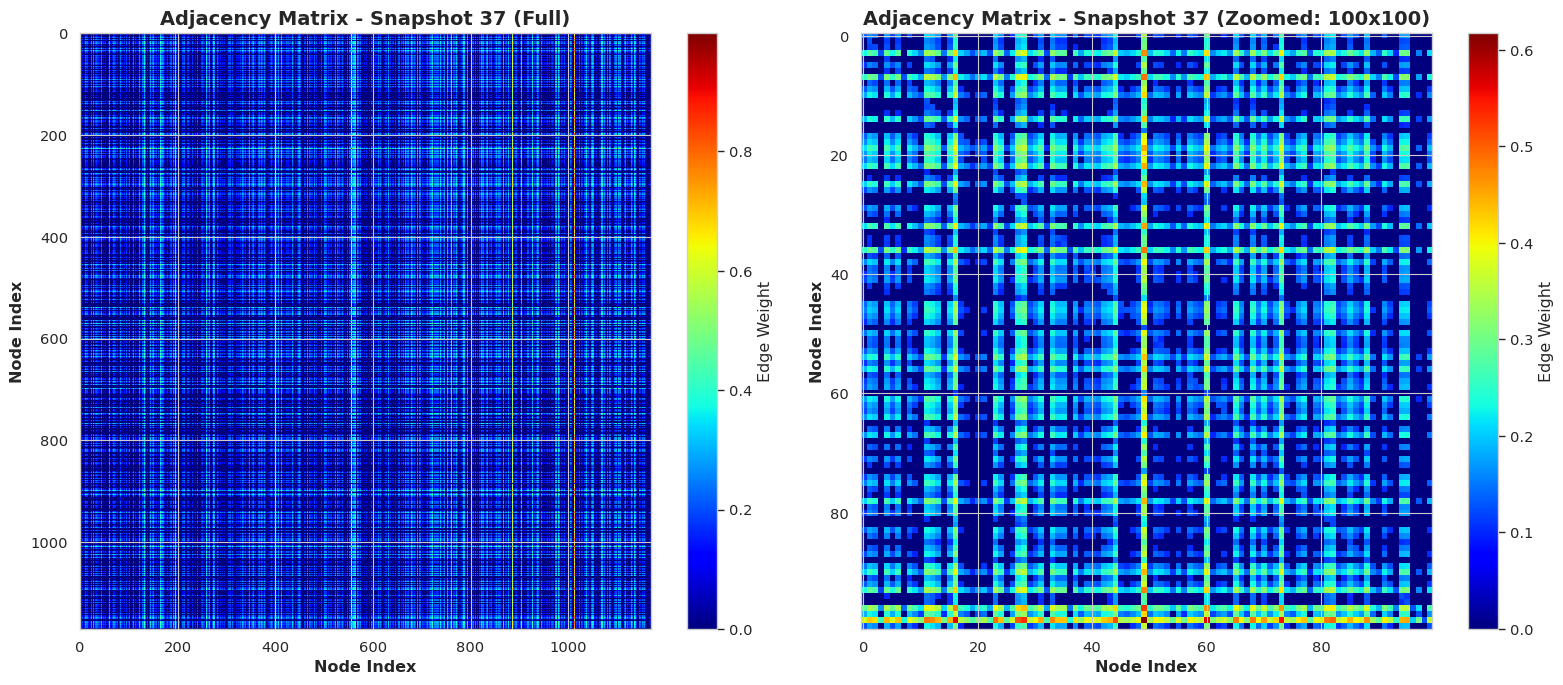


=== Snapshot 37 Statistics ===
Number of Nodes: 1171
Number of Edges: 711649
Connectivity: 0.5194
Sparsity: 0.4806
Non-zero entries: 711649
Max edge weight: 0.9982
Mean edge weight (non-zero): 0.2068


In [18]:
# Visualize a Random Snapshot Adjacency Matrix
random_snapshot_idx = np.random.randint(0, train_analyzer.num_snapshots)
adj_matrix = train_adjs[random_snapshot_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full adjacency matrix
im1 = axes[0].imshow(adj_matrix, cmap='jet', aspect='auto', interpolation='nearest')
axes[0].set_title(f'Adjacency Matrix - Snapshot {random_snapshot_idx} (Full)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Node Index', fontweight='bold')
axes[0].set_ylabel('Node Index', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Edge Weight')

# Zoomed in view (first 100x100 nodes)
zoom_size = min(100, adj_matrix.shape[0])
adj_zoom = adj_matrix[:zoom_size, :zoom_size]
im2 = axes[1].imshow(adj_zoom, cmap='jet', aspect='auto', interpolation='nearest')
axes[1].set_title(f'Adjacency Matrix - Snapshot {random_snapshot_idx} (Zoomed: {zoom_size}x{zoom_size})', 
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Node Index', fontweight='bold')
axes[1].set_ylabel('Node Index', fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Edge Weight')

plt.tight_layout()
save_figure('snapshot_adjacency_matrix_visualization')
plt.show()

# Print statistics about this snapshot
snapshot_info = train_analyzer.get_snapshot_info(random_snapshot_idx)
print(f"\n=== Snapshot {random_snapshot_idx} Statistics ===")
print(f"Number of Nodes: {snapshot_info['num_nodes']}")
print(f"Number of Edges: {snapshot_info['num_edges']}")
print(f"Connectivity: {snapshot_info['connectivity']:.4f}")
print(f"Sparsity: {1.0 - (snapshot_info['num_edges'] / (snapshot_info['num_nodes'] * (snapshot_info['num_nodes'] - 1))):.4f}")
print(f"Non-zero entries: {np.count_nonzero(adj_matrix)}")
print(f"Max edge weight: {np.max(adj_matrix):.4f}")
print(f"Mean edge weight (non-zero): {adj_matrix[adj_matrix > 0].mean():.4f}")

### 1.4. Connectivity Comparison

Figure saved to thesis_figures/NYSE/cross_dataset_connectivity.pdf


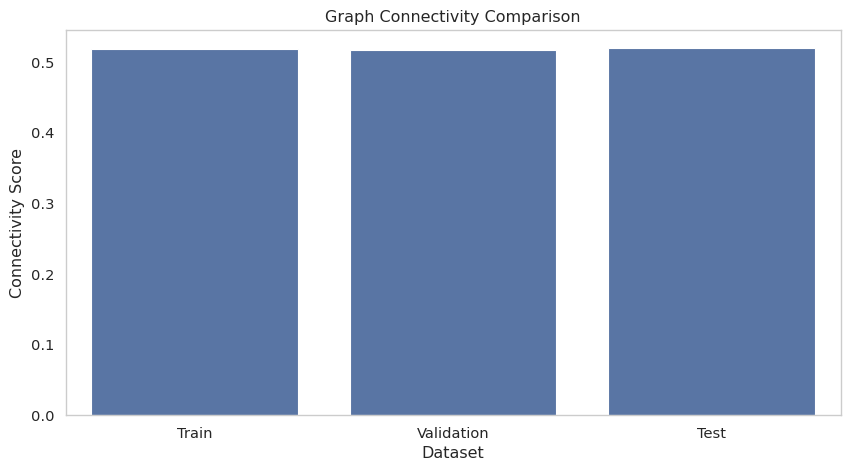

,Connectivity
Train,0.518142
Validation,0.516847
Test,0.519023


In [19]:
# Graph Connectivity Comparison
connectivity_scores = {name: analyzer.get_connectivity() for name, analyzer in analyzers.items()}
connectivity_df = pd.DataFrame.from_dict(connectivity_scores, orient='index', columns=['Connectivity'])

plt.figure(figsize=(10, 5))
sns.barplot(x=connectivity_df.index, y=connectivity_df['Connectivity'])
plt.title('Graph Connectivity Comparison')
plt.ylabel('Connectivity Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_connectivity')
plt.show()

display(connectivity_df)

---
## 2. Feature Analysis

In [20]:
# Focus on training set for deep feature analysis
features_df = train_analyzer.analyze_node_features()

# Feature Statistics
feature_stats = features_df[train_analyzer.features].describe()
print("--- Feature Statistics (Training Set) ---")
display(feature_stats)

--- Feature Statistics (Training Set) ---


,Close,High,Low,Open,Volume
count,256449.000000,256449.000000,256449.000000,256449.000000,256449.000000
mean,0.683789,0.683781,0.684008,0.684013,0.441603
std,0.191507,0.190806,0.192015,0.191616,0.380910
min,-0.377504,-0.377876,-0.378200,-0.380427,-0.650100
25%,0.567065,0.567889,0.566376,0.567001,0.169529
50%,0.674627,0.674717,0.674971,0.674819,0.388195
75%,0.800074,0.799249,0.800791,0.800218,0.652546
max,1.882572,1.843889,1.807249,1.843962,3.147901


Figure saved to thesis_figures/NYSE/feature_distributions.pdf


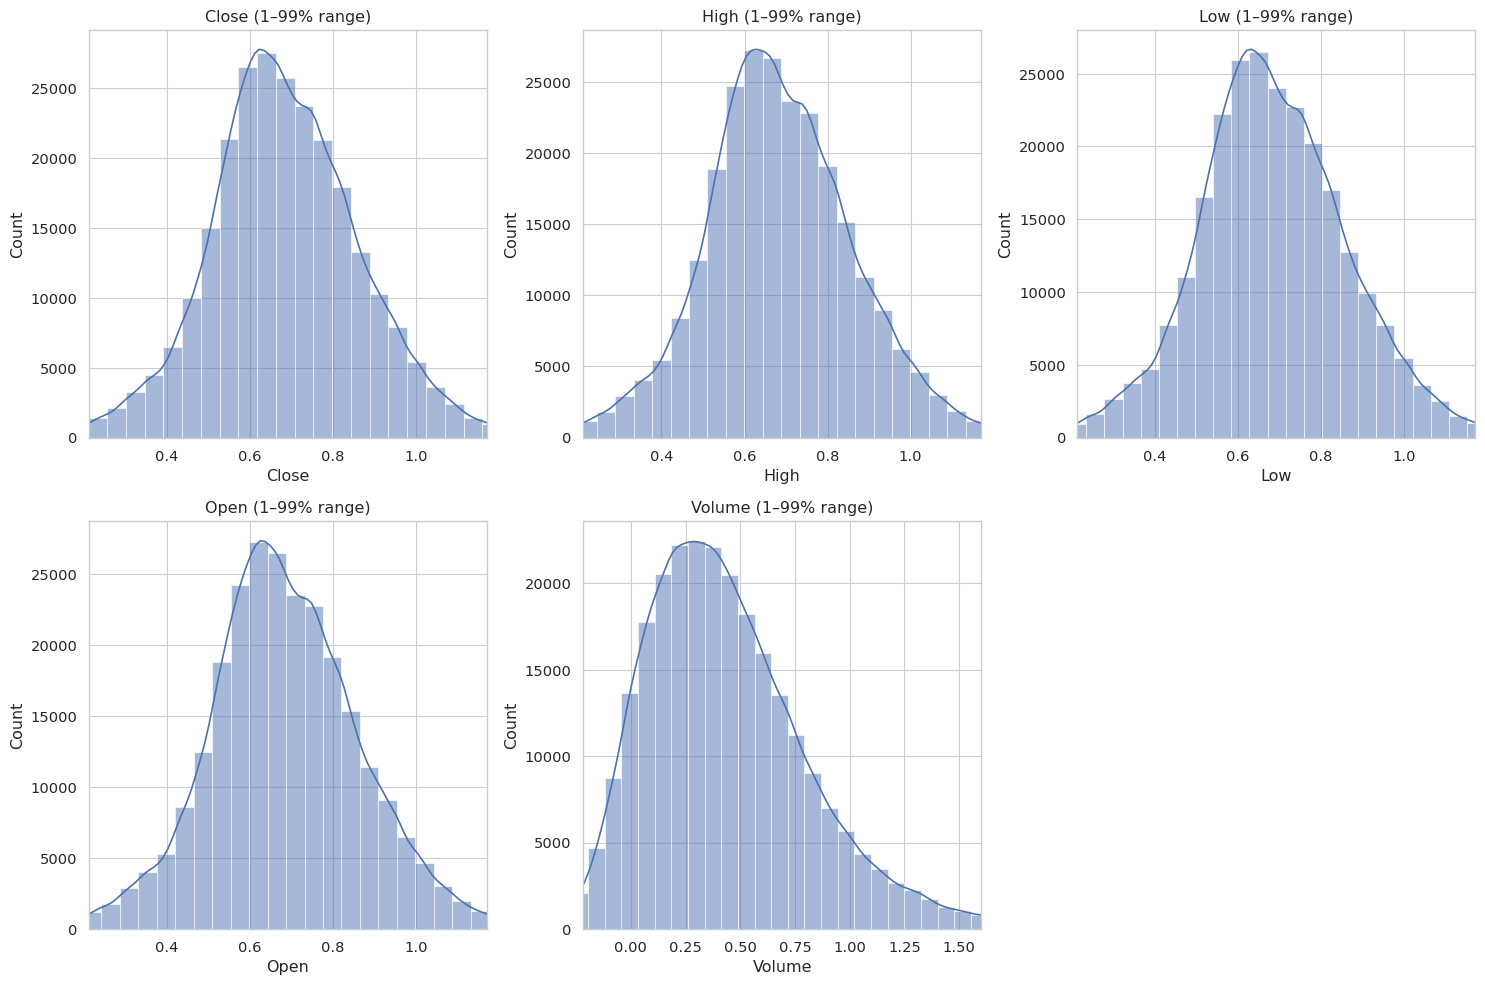

In [21]:
# Feature Distributions
plt.figure(figsize=(15, 10))

for i, feature in enumerate(train_analyzer.features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(features_df[feature], kde=True, bins=50)
    q_low, q_high = features_df[feature].quantile([0.01, 0.99])
    plt.xlim(q_low, q_high)
    plt.title(f'{feature} (1–99% range)')
    
plt.tight_layout()
save_figure('feature_distributions')
plt.show()

Figure saved to thesis_figures/NYSE/feature_correlation_matrix.pdf


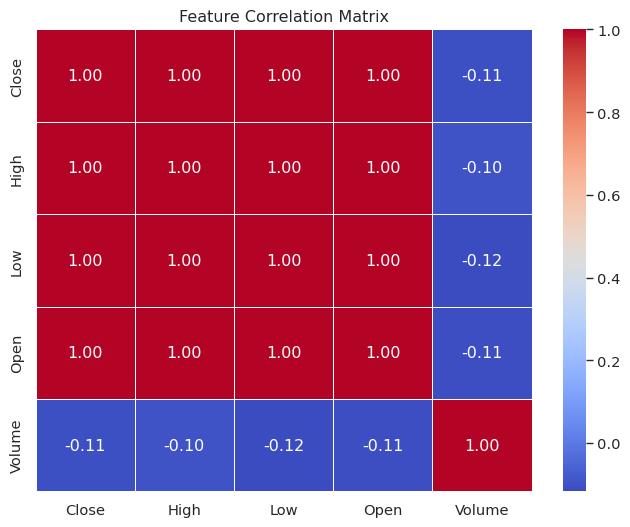

In [22]:
# Feature Correlation
correlation_matrix = features_df[train_analyzer.features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix')
save_figure('feature_correlation_matrix')
plt.show()

Figure saved to thesis_figures/NYSE/feature_entropy.pdf


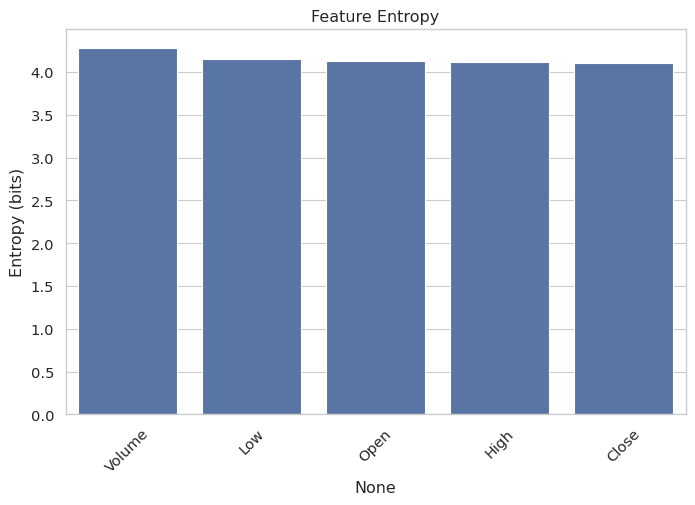

--- Feature Entropy ---


,Entropy
Volume,4.283300
Low,4.156007
Open,4.126438
High,4.120763
Close,4.103533


In [23]:
# Feature Entropy
def calculate_entropy(series, bins=50):
    """Calculates the entropy of a continuous series."""
    counts = np.histogram(series, bins=bins)[0]
    return entropy(counts, base=2)

feature_entropy = {feat: calculate_entropy(features_df[feat]) for feat in train_analyzer.features}
entropy_series = pd.Series(feature_entropy).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=entropy_series.index, y=entropy_series.values)
plt.title('Feature Entropy')
plt.ylabel('Entropy (bits)')
plt.xticks(rotation=45)
save_figure('feature_entropy')
plt.show()

print("--- Feature Entropy ---")
display(entropy_series.to_frame('Entropy'))

---
## 3. Graph Topology Analysis

### 3.1. Homophily

Figure saved to thesis_figures/NYSE/cross_dataset_homophily.pdf


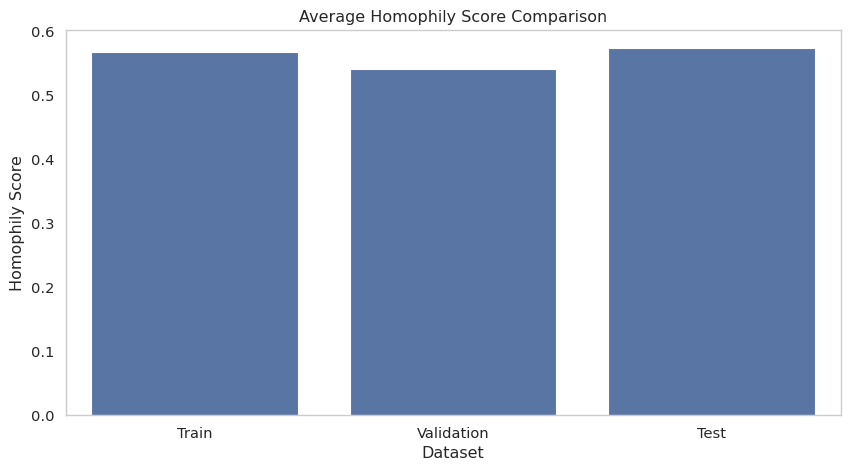

--- Average Homophily Scores ---


,Average Homophily
Train,0.566804
Validation,0.540334
Test,0.573279


In [24]:
# Compare Average Homophily Across Datasets
homophily_scores = {name: analyzer.get_average_homophily_score() for name, analyzer in analyzers.items()}
homophily_df = pd.DataFrame.from_dict(homophily_scores, orient='index', columns=['Average Homophily'])

plt.figure(figsize=(10, 5))
sns.barplot(x=homophily_df.index, y=homophily_df['Average Homophily'])
plt.title('Average Homophily Score Comparison')
plt.ylabel('Homophily Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_homophily')
plt.show()

print("--- Average Homophily Scores ---")
display(homophily_df)

Figure saved to thesis_figures/NYSE/temporal_homophily_train.pdf


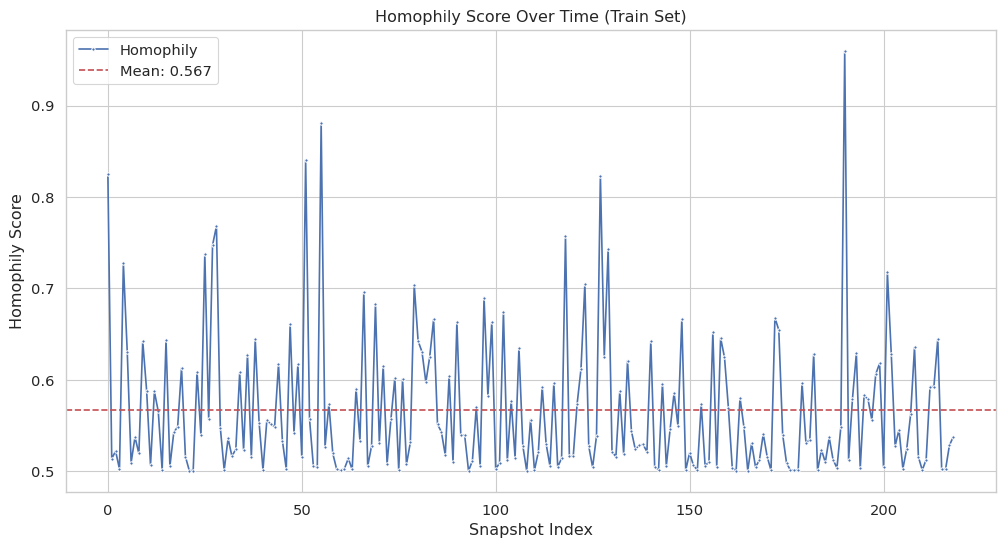

/tmp/ipykernel_3634451/1801966744.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved to thesis_figures/NYSE/hist_homophily_train.pdf


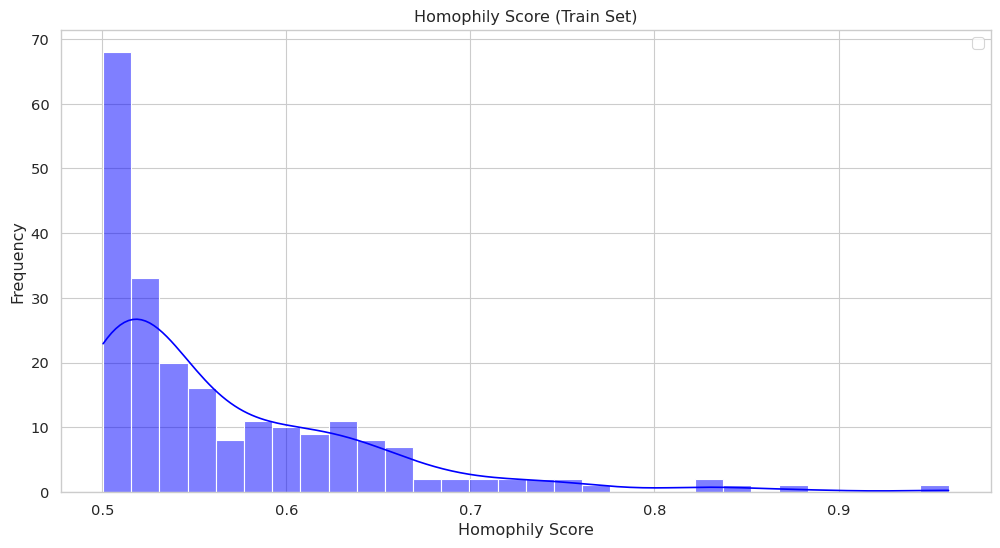

In [25]:
# Homophily Score Over Time (Train Set)
homophily_over_time = [train_analyzer.get_homophily_score(i) for i in range(train_analyzer.num_snapshots)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=homophily_over_time, marker='.', linestyle='-', label='Homophily')
plt.axhline(y=np.mean(homophily_over_time), color='r', linestyle='--', label=f'Mean: {np.mean(homophily_over_time):.3f}')
plt.title('Homophily Score Over Time (Train Set)')
plt.xlabel('Snapshot Index')
plt.ylabel('Homophily Score')
plt.legend()
save_figure('temporal_homophily_train')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(homophily_over_time, bins=30, kde=True, color='blue', alpha=0.5)
plt.title('Homophily Score (Train Set)')
plt.xlabel('Homophily Score')
plt.ylabel('Frequency')
plt.legend()
save_figure('hist_homophily_train')
plt.show()

/tmp/ipykernel_3634451/3332766672.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['Train', 'Validation', 'Test'],


Figure saved to thesis_figures/NYSE/homophily_comprehensive_all_splits.pdf


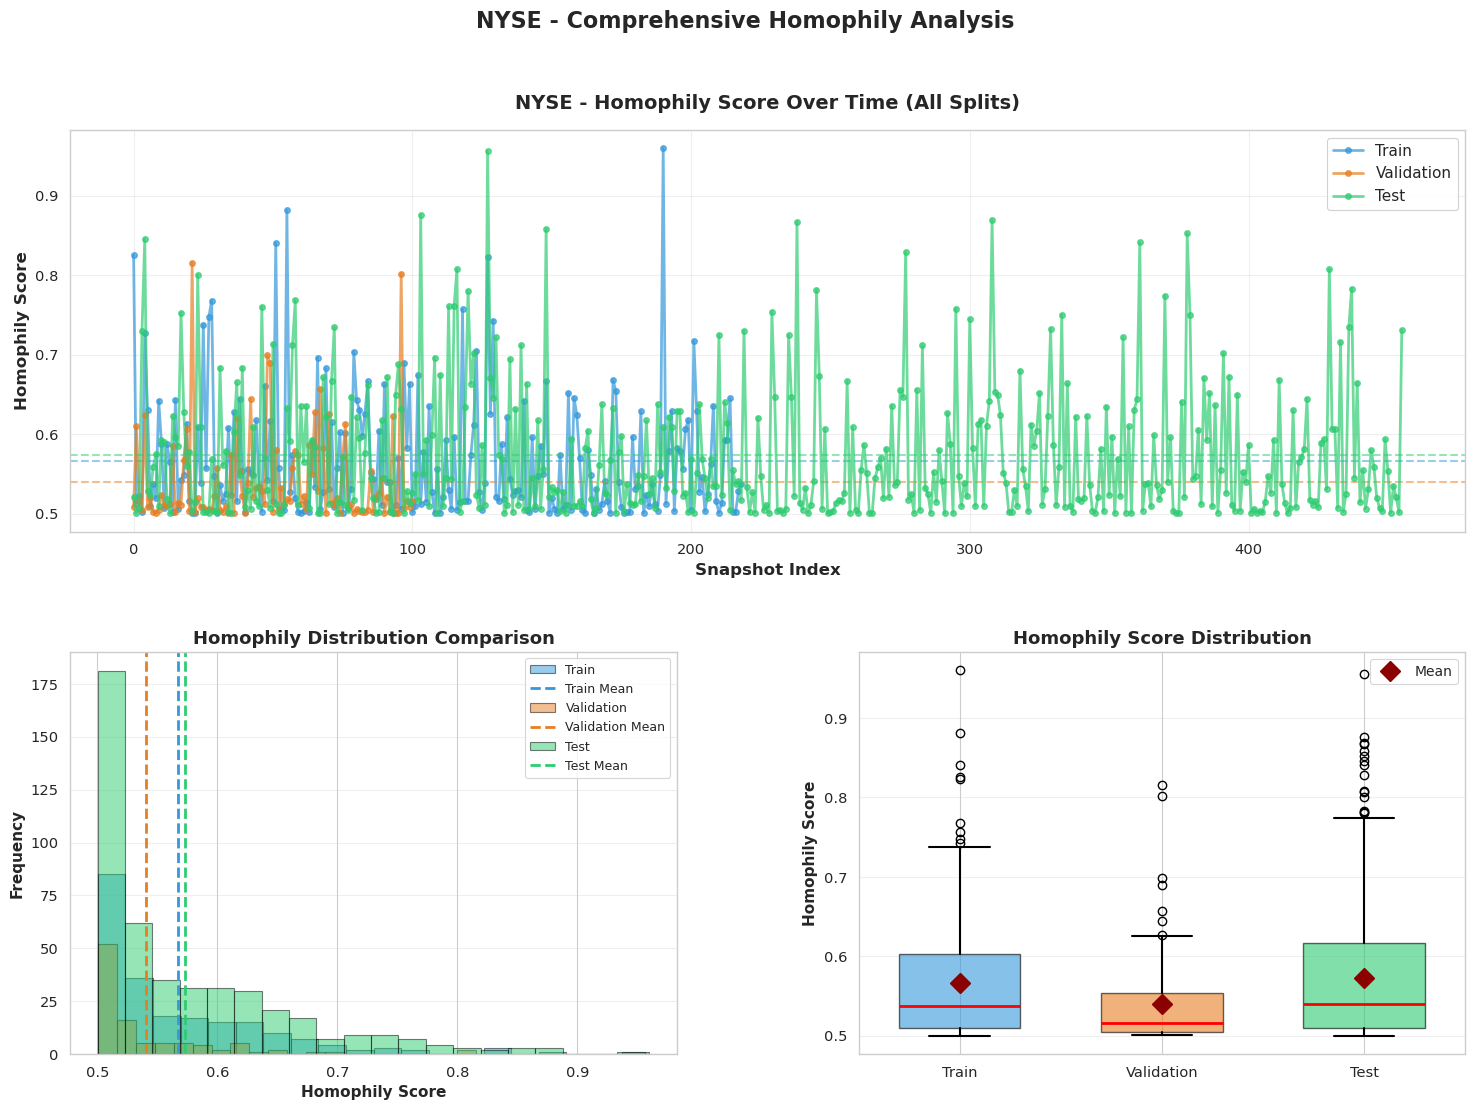


NYSE - HOMOPHILY STATISTICS SUMMARY
+------------+--------+---------+--------+--------+-------------+
|   Split    |  Mean  | Std Dev |  Min   |  Max   | # Snapshots |
+------------+--------+---------+--------+--------+-------------+
|   Train    | 0.5668 | 0.0773  | 0.5004 | 0.9598 |     219     |
| Validation | 0.5403 | 0.0587  | 0.5005 | 0.8157 |     101     |
|    Test    | 0.5733 | 0.0833  | 0.5003 | 0.9559 |     456     |
+------------+--------+---------+--------+--------+-------------+

--- LaTeX Table: Homophily Statistics ---

\begin{table}[h]
    \centering
    \begin{tabular}{lcccc}
        \toprule
        \textbf{Split} & \textbf{Mean} & \textbf{Std} & \textbf{Min} & \textbf{Max} \\
        \midrule
        Train        & 0.5668 & 0.0773 & 0.5004 & 0.9598 \\
        Validation   & 0.5403 & 0.0587 & 0.5005 & 0.8157 \\
        Test         & 0.5733 & 0.0833 & 0.5003 & 0.9559 \\
        \bottomrule
    \end{tabular}
    \caption{Homophily score statistics for NYSE dataset ac

In [26]:
# ===================================================================
# IMPROVED HOMOPHILY VISUALIZATION - ALL SPLITS
# ===================================================================

# Compute homophily scores for all splits
homophily_data = {}
for name, analyzer in analyzers.items():
    homophily_scores = [analyzer.get_homophily_score(i) for i in range(analyzer.num_snapshots)]
    homophily_data[name] = {
        'scores': homophily_scores,
        'mean': np.mean(homophily_scores),
        'std': np.std(homophily_scores),
        'min': np.min(homophily_scores),
        'max': np.max(homophily_scores)
    }

# Create comprehensive visualization with 2 rows x 2 columns
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# ===================================================================
# PLOT 1: Time Series for All Splits (Top Left)
# ===================================================================
ax1 = fig.add_subplot(gs[0, :])  # Span full width of first row

colors = {'Train': '#3498db', 'Validation': '#e67e22', 'Test': '#2ecc71'}
for name, data in homophily_data.items():
    ax1.plot(data['scores'], marker='.', linestyle='-', label=name, 
             color=colors[name], linewidth=2, markersize=8, alpha=0.7)
    # Add mean line
    ax1.axhline(y=data['mean'], color=colors[name], linestyle='--', 
               linewidth=1.5, alpha=0.5)

ax1.set_title(f'{MARKET} - Homophily Score Over Time (All Splits)', 
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Snapshot Index', fontsize=12, fontweight='bold')
ax1.set_ylabel('Homophily Score', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# ===================================================================
# PLOT 2: Distribution Comparison (Bottom Left)
# ===================================================================
ax2 = fig.add_subplot(gs[1, 0])

# Prepare data for histogram
all_scores = []
all_labels = []
for name, data in homophily_data.items():
    all_scores.extend(data['scores'])
    all_labels.extend([name] * len(data['scores']))

scores_df = pd.DataFrame({'Homophily': all_scores, 'Split': all_labels})

# Plot overlapping histograms
for name, color in colors.items():
    subset = scores_df[scores_df['Split'] == name]['Homophily']
    ax2.hist(subset, bins=20, alpha=0.5, label=name, color=color, edgecolor='black')
    # Add mean line
    ax2.axvline(x=homophily_data[name]['mean'], color=color, linestyle='--', 
               linewidth=2, label=f'{name} Mean')

ax2.set_title('Homophily Distribution Comparison', fontsize=13, fontweight='bold')
ax2.set_xlabel('Homophily Score', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, axis='y', alpha=0.3)

# ===================================================================
# PLOT 3: Box Plot Comparison (Bottom Right)
# ===================================================================
ax3 = fig.add_subplot(gs[1, 1])

# Create box plot
box_data = [homophily_data[name]['scores'] for name in ['Train', 'Validation', 'Test']]
bp = ax3.boxplot(box_data, labels=['Train', 'Validation', 'Test'],
                 patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

# Color boxes
for patch, name in zip(bp['boxes'], ['Train', 'Validation', 'Test']):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.6)

# Add mean markers
means = [homophily_data[name]['mean'] for name in ['Train', 'Validation', 'Test']]
ax3.plot(range(1, 4), means, 'D', color='darkred', markersize=10, 
        label='Mean', zorder=3)

ax3.set_title('Homophily Score Distribution', fontsize=13, fontweight='bold')
ax3.set_ylabel('Homophily Score', fontsize=11, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'{MARKET} - Comprehensive Homophily Analysis', 
            fontsize=16, fontweight='bold', y=0.98)

save_figure('homophily_comprehensive_all_splits')
plt.show()

# ===================================================================
# PRINT STATISTICS TABLE
# ===================================================================
print("\n" + "="*80)
print(f"{MARKET} - HOMOPHILY STATISTICS SUMMARY")
print("="*80)

stats_table = []
for name in ['Train', 'Validation', 'Test']:
    data = homophily_data[name]
    stats_table.append([
        name,
        f"{data['mean']:.4f}",
        f"{data['std']:.4f}",
        f"{data['min']:.4f}",
        f"{data['max']:.4f}",
        f"{len(data['scores'])}"
    ])

from tabulate import tabulate
headers = ['Split', 'Mean', 'Std Dev', 'Min', 'Max', '# Snapshots']
print(tabulate(stats_table, headers=headers, tablefmt='pretty'))
print("="*80 + "\n")

# ===================================================================
# LATEX TABLE GENERATION
# ===================================================================
print("--- LaTeX Table: Homophily Statistics ---\n")

latex_table = r"\begin{table}[h]" + "\n"
latex_table += r"    \centering" + "\n"
latex_table += r"    \begin{tabular}{lcccc}" + "\n"
latex_table += r"        \toprule" + "\n"
latex_table += r"        \textbf{Split} & \textbf{Mean} & \textbf{Std} & \textbf{Min} & \textbf{Max} \\" + "\n"
latex_table += r"        \midrule" + "\n"

for name in ['Train', 'Validation', 'Test']:
    data = homophily_data[name]
    latex_table += f"        {name:12s} & {data['mean']:.4f} & {data['std']:.4f} & {data['min']:.4f} & {data['max']:.4f} \\\\\n"

latex_table += r"        \bottomrule" + "\n"
latex_table += r"    \end{tabular}" + "\n"
latex_table += f"    \\caption{{Homophily score statistics for {MARKET} dataset across train, validation, and test splits.}}\n"
latex_table += f"    \\label{{tab:{MARKET.lower()}_homophily_stats}}\n"
latex_table += r"\end{table}"

print(latex_table)

# Save LaTeX table to file
latex_file_path = FIGURE_OUTPUT_PATH / f"{MARKET}_homophily_stats.tex"
with open(latex_file_path, 'w') as f:
    f.write(latex_table)
print(f"\n✓ LaTeX table saved to: {latex_file_path}")


### 3.2. Authorities and Hubs

In [27]:
# Calculate average degrees across all snapshots for train set
avg_degree_df_train = train_analyzer.get_average_node_degrees()

# Identify Top 10 Authorities (Highest In-Degree)
top_authorities_train = avg_degree_df_train.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) - Train Set ---")
display(top_authorities_train[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# Identify Top 10 Hubs (Highest Out-Degree)
top_hubs_train = avg_degree_df_train.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) - Train Set ---")
display(top_hubs_train[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

--- Top 10 Authorities (Highest In-Degree) - Train Set ---


,ticker,avg_in_degree,avg_weighted_in_degree
1012,TCAP,1169.630137,814.324341
555,JBR,1168.324201,719.677734
885,PYS,1167.630137,650.694946
474,GYC,1166.648402,454.966614
760,NOM,1166.159817,434.430298
49,ALX,1161.242009,384.307861
195,CBI,1161.077626,604.989746
132,BH,1160.926941,384.808105
787,NXN,1159.908676,380.908020
415,FMY,1158.529680,373.806763



--- Top 10 Hubs (Highest Out-Degree) - Train Set ---


,ticker,avg_out_degree,avg_weighted_out_degree
98,BAC,1171.000000,471.864594
228,CMG,1169.899543,436.300842
386,F,1168.803653,409.491913
1009,T,1167.187215,392.374420
1143,WMT,1167.127854,389.521362
549,ITUB,1167.063927,391.446564
835,PFE,1166.278539,382.849365
1133,WFC,1165.077626,377.822510
1159,X,1162.958904,367.828888
184,C,1162.849315,365.710785


Figure saved to thesis_figures/NYSE/hubs_vs_authorities_train.pdf


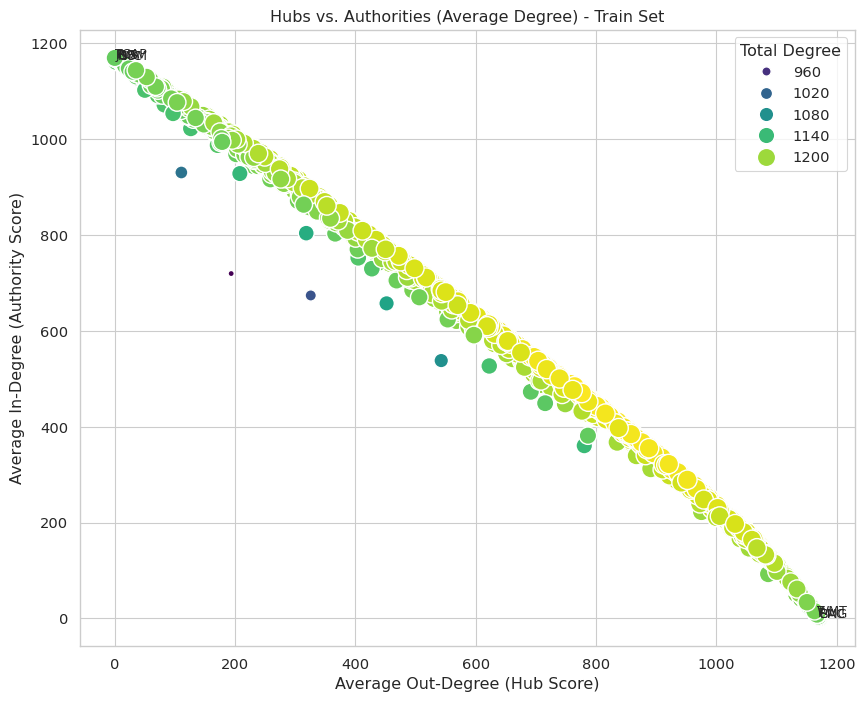

In [28]:
# Visualize Hubs vs Authorities
avg_degree_df_train['total_degree'] = avg_degree_df_train['avg_in_degree'] + avg_degree_df_train['avg_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df_train, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

# Annotate top 5 hubs and authorities
for i, row in avg_degree_df_train.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df_train.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) - Train Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_train')
plt.show()

Figure saved to thesis_figures/NYSE/hubs_vs_authorities_weighted_test.pdf


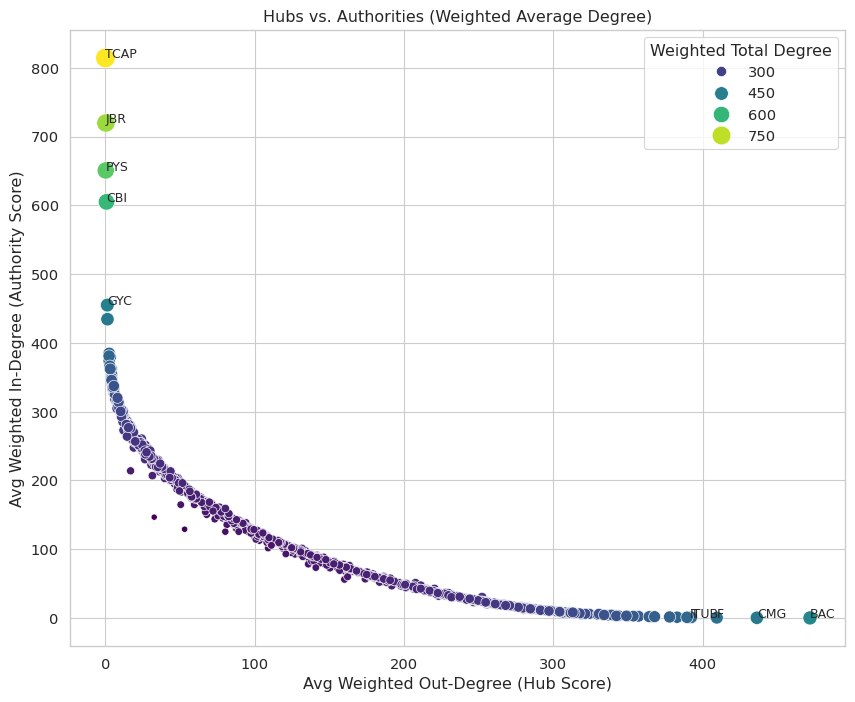

In [29]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df_train['weighted_total_degree'] = avg_degree_df_train['avg_weighted_in_degree'] + avg_degree_df_train['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df_train,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df_train.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df_train.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_test')
plt.show()

In [30]:
# Calculate average degrees for test set
avg_degree_df_test = test_analyzer.get_average_node_degrees()

# Identify Top 10 Authorities (Test Set)
top_authorities_test = avg_degree_df_test.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) - Test Set ---")
display(top_authorities_test[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# Identify Top 10 Hubs (Test Set)
top_hubs_test = avg_degree_df_test.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) - Test Set ---")
display(top_hubs_test[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

--- Top 10 Authorities (Highest In-Degree) - Test Set ---


,ticker,avg_in_degree,avg_weighted_in_degree
1012,TCAP,1170.000000,819.358215
555,JBR,1168.739035,698.332947
474,GYC,1166.932018,476.737518
760,NOM,1164.712719,414.358490
787,NXN,1159.710526,384.057251
710,MTR,1159.315789,385.981598
204,CEE,1156.778509,374.570343
585,KF,1156.280702,383.179871
415,FMY,1154.587719,375.485016
721,MXE,1151.962719,361.742767



--- Top 10 Hubs (Highest Out-Degree) - Test Set ---


,ticker,avg_out_degree,avg_weighted_out_degree
98,BAC,1170.848684,441.802826
1009,T,1169.635965,421.985260
386,F,1169.201754,414.951538
228,CMG,1168.239035,409.665649
549,ITUB,1166.070175,385.333405
835,PFE,1165.750000,381.734283
1143,WMT,1164.940789,380.147339
1133,WFC,1164.265351,373.138397
457,GME,1160.331140,367.115112
184,C,1160.070175,353.171051


Figure saved to thesis_figures/NYSE/hubs_vs_authorities_test.pdf


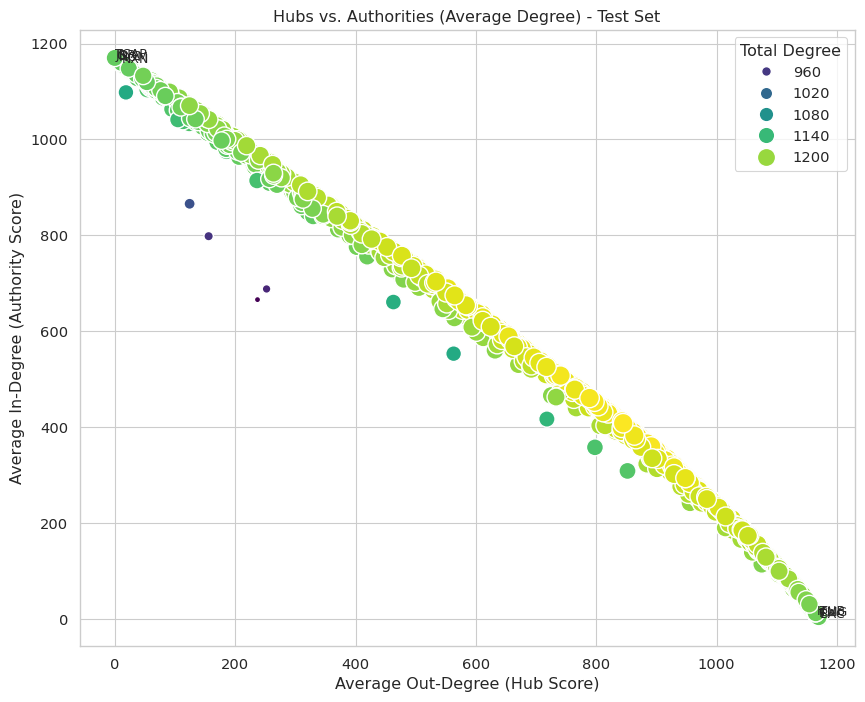

In [31]:
# Visualize Hubs vs Authorities (Test Set)
avg_degree_df_test['total_degree'] = avg_degree_df_test['avg_in_degree'] + avg_degree_df_test['avg_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df_test, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

for i, row in avg_degree_df_test.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df_test.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) - Test Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_test')
plt.show()

Figure saved to thesis_figures/NYSE/hubs_vs_authorities_weighted_test.pdf


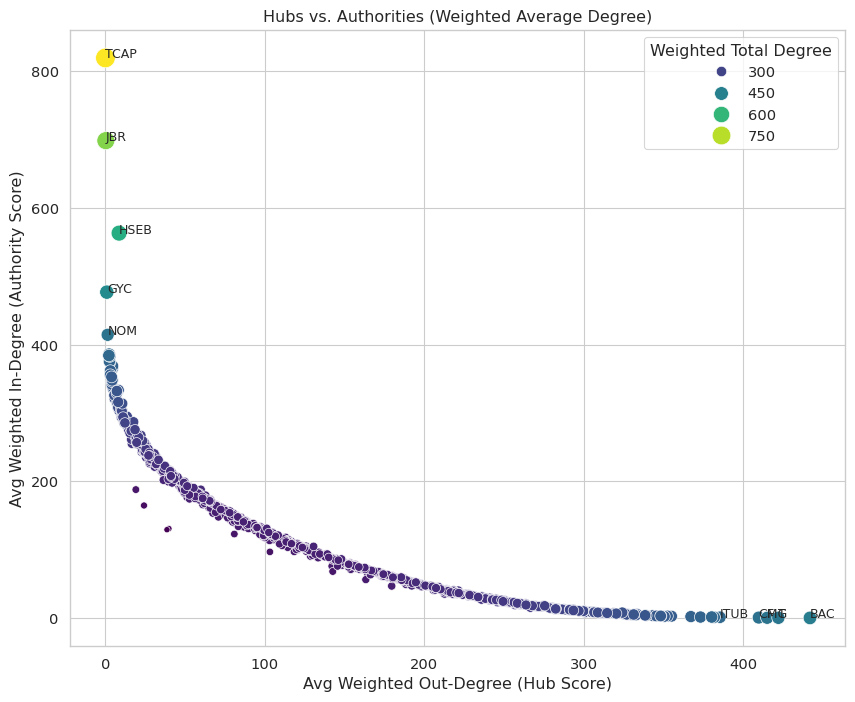

In [32]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df_test['weighted_total_degree'] = avg_degree_df_test['avg_weighted_in_degree'] + avg_degree_df_test['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df_test,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df_test.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df_test.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_test')
plt.show()

### 3.3. Centrality

In [33]:
# Multi-snapshot centrality averaging
# Select snapshots for centrality analysis (evenly spaced)
NUM_SNAPSHOTS_CENTRALITY = 10
snapshot_indices = np.linspace(0, train_analyzer.num_snapshots - 1, NUM_SNAPSHOTS_CENTRALITY, dtype=int)

print(f"Computing centrality across {NUM_SNAPSHOTS_CENTRALITY} snapshots...")
print(f"Snapshot indices: {snapshot_indices}")

# Initialize storage for centrality values
degree_centralities = []
eigenvector_centralities = []
betweenness_centralities = []

for idx in snapshot_indices:
    print(f"Processing snapshot {idx}...", end='\r')
    G = nx.from_numpy_array(train_adjs[idx], create_using=nx.DiGraph)
    
    degree_centralities.append(nx.degree_centrality(G))
    eigenvector_centralities.append(nx.eigenvector_centrality(G, weight='weight', max_iter=1000))
    betweenness_centralities.append(nx.betweenness_centrality(G, weight='weight', k=100))  # Approximate with k=100

print("\nCentrality computation complete!")

# Average centralities across snapshots
avg_degree_centrality = pd.DataFrame(degree_centralities).mean()
avg_eigenvector_centrality = pd.DataFrame(eigenvector_centralities).mean()
avg_betweenness_centrality = pd.DataFrame(betweenness_centralities).mean()

centrality_df = pd.DataFrame({
    'Degree': avg_degree_centrality,
    'Eigenvector': avg_eigenvector_centrality,
    'Betweenness': avg_betweenness_centrality
})

print("\n--- Top 10 Nodes by Average Centrality Measures ---")
for col in centrality_df.columns:
    print(f"\n--- Top 10 by {col} Centrality ---")
    top_nodes = centrality_df[col].nlargest(10)
    top_nodes.index = [train_analyzer.index_to_stock[i] for i in top_nodes.index]
    display(top_nodes)

Computing centrality across 10 snapshots...
Snapshot indices: [  0  24  48  72  96 121 145 169 193 218]
Processing snapshot 218...
Centrality computation complete!

--- Top 10 Nodes by Average Centrality Measures ---

--- Top 10 by Degree Centrality ---


MAC    1.069231
WHR    1.068120
BXP    1.067607
SLG    1.067607
FNV    1.067521
FMC    1.067436
AVB    1.067350
EXR    1.067350
HUM    1.067265
ECL    1.067009
Name: Degree, dtype: float64


--- Top 10 by Eigenvector Centrality ---


TCAP    0.433442
JBR     0.365065
PYS     0.311189
CBI     0.202071
GYC     0.176900
NOM     0.158543
BH      0.127534
BRT     0.124483
NXN     0.123951
ALX     0.119124
Name: Eigenvector, dtype: float64


--- Top 10 by Betweenness Centrality ---


CW     0.056927
IDA    0.055169
BIO    0.041080
TM     0.039856
ASR    0.039701
ORA    0.037884
DLX    0.037409
PAC    0.036995
PB     0.032883
ENS    0.032842
Name: Betweenness, dtype: float64

Figure saved to thesis_figures/NYSE/centrality_distributions_averaged.pdf


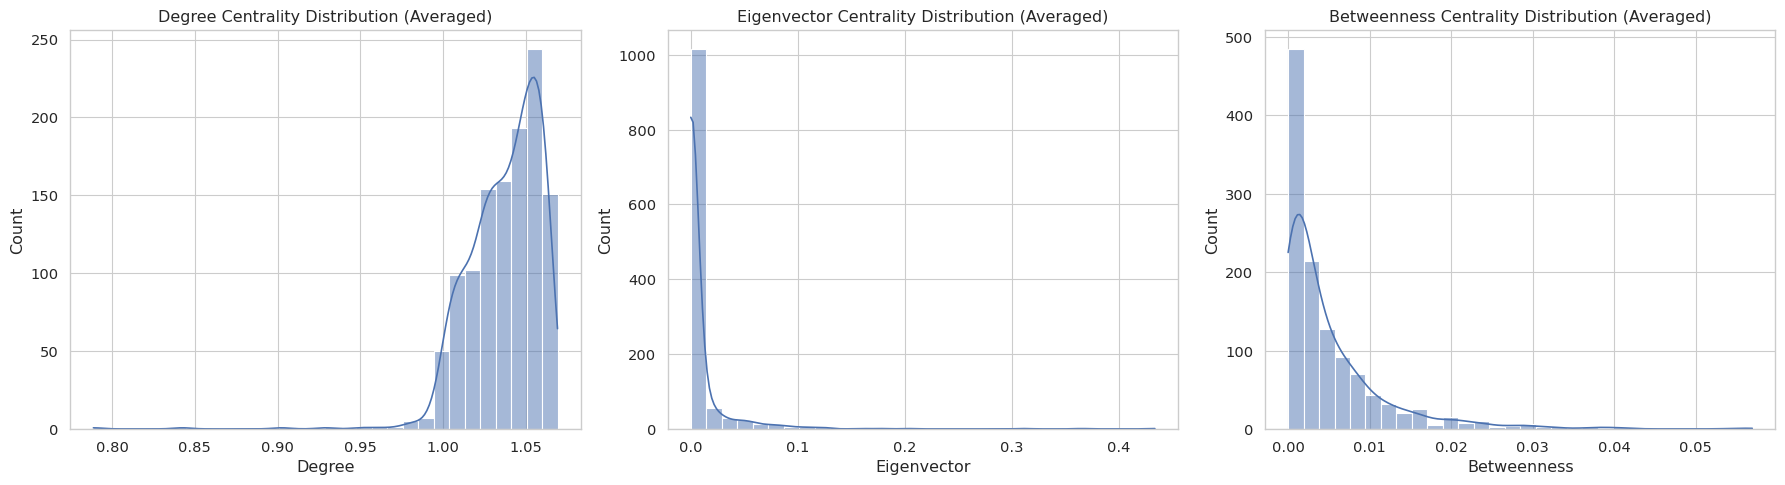

In [34]:
# Plotting Centrality Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(centrality_df.columns):
    sns.histplot(centrality_df[col], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'{col} Centrality Distribution (Averaged)')
plt.tight_layout()
save_figure('centrality_distributions_averaged')
plt.show()

Figure saved to thesis_figures/NYSE/centrality_ranking_stability.pdf


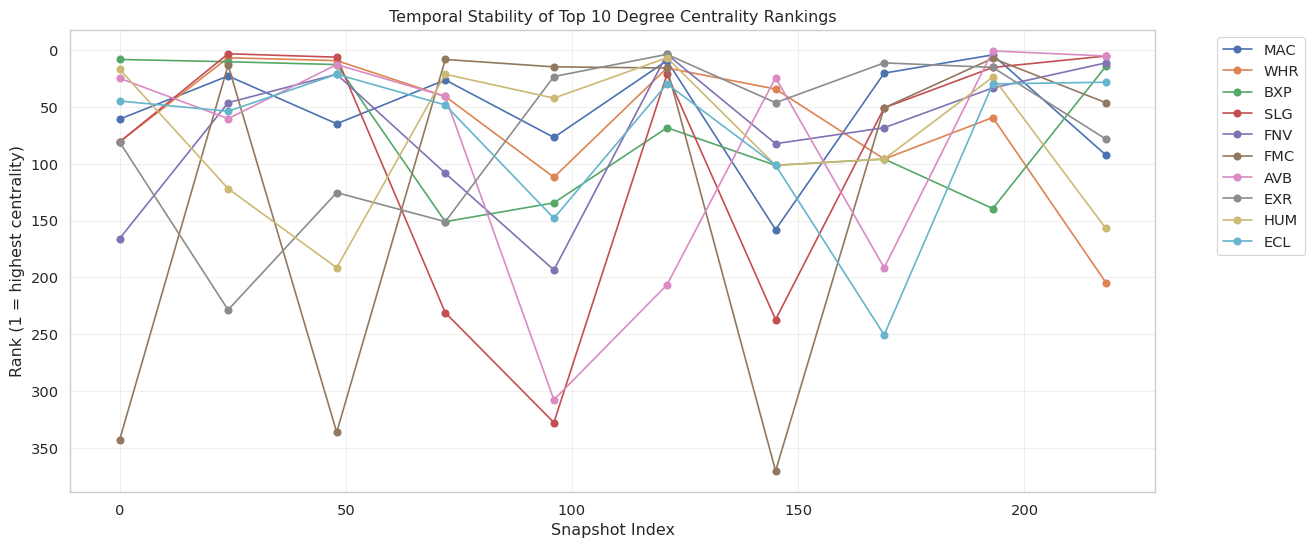

In [35]:
# Analyze temporal stability of centrality rankings
# For top 10 degree centrality nodes, track their ranking over time
top_10_nodes = centrality_df['Degree'].nlargest(10).index.tolist()
top_10_tickers = [train_analyzer.index_to_stock[i] for i in top_10_nodes]

degree_rankings_over_time = []
for idx in snapshot_indices:
    G = nx.from_numpy_array(train_adjs[idx], create_using=nx.DiGraph)
    deg_cent = pd.Series(nx.degree_centrality(G))
    rankings = {node: deg_cent.rank(ascending=False)[node] for node in top_10_nodes}
    degree_rankings_over_time.append(rankings)

ranking_df = pd.DataFrame(degree_rankings_over_time, index=snapshot_indices)
ranking_df.columns = top_10_tickers

plt.figure(figsize=(14, 6))
for ticker in ranking_df.columns:
    plt.plot(ranking_df.index, ranking_df[ticker], marker='o', label=ticker)
plt.gca().invert_yaxis()
plt.title('Temporal Stability of Top 10 Degree Centrality Rankings')
plt.xlabel('Snapshot Index')
plt.ylabel('Rank (1 = highest centrality)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
save_figure('centrality_ranking_stability')
plt.show()

---
## 4. Temporal Analysis of the Graph

### 4.1. Temporal Evolution of the Topology

Figure saved to thesis_figures/NYSE/temporal_adj_stability.pdf


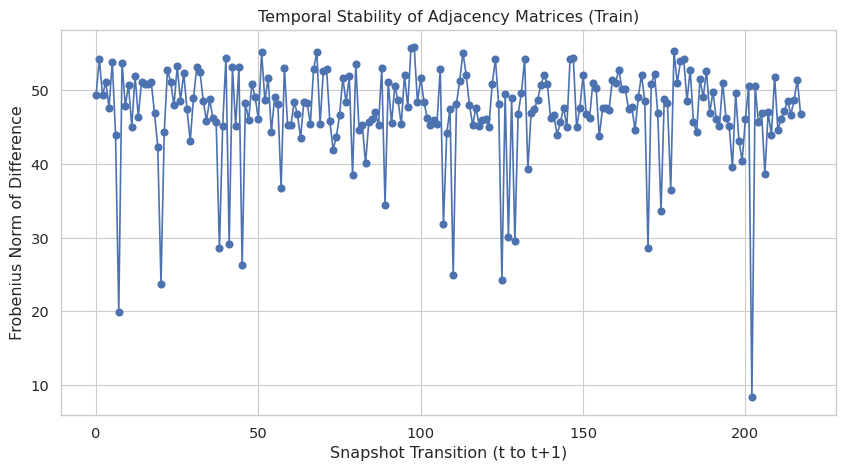

In [36]:
# Adjacency Matrix Stability
adj_diffs = []
for i in range(1, len(train_adjs)):
    diff = np.linalg.norm(train_adjs[i] - train_adjs[i-1], 'fro')
    adj_diffs.append(diff)

plt.figure(figsize=(10, 5))
plt.plot(adj_diffs, marker='o', linestyle='-')
plt.title('Temporal Stability of Adjacency Matrices (Train)')
plt.xlabel('Snapshot Transition (t to t+1)')
plt.ylabel('Frobenius Norm of Difference')
save_figure('temporal_adj_stability')
plt.show()

Figure saved to thesis_figures/NYSE/temporal_feature_trend.pdf


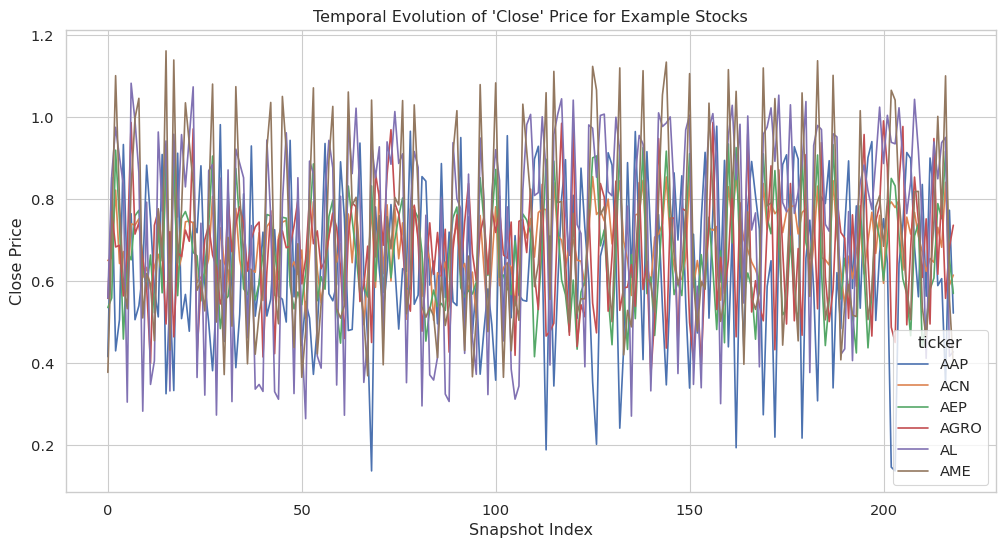

In [37]:
# Feature Evolution Over Time (example stocks)
example_stocks = [train_analyzer.index_to_stock[i] for i in [0, 10, 20, 30, 40, 50]]
ts_data = pd.DataFrame()
for stock in example_stocks:
    stock_ts = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    ts_data = pd.concat([ts_data, stock_ts])

plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_data, x='snapshot', y='value', hue='ticker')
plt.title("Temporal Evolution of 'Close' Price for Example Stocks")
plt.xlabel('Snapshot Index')
plt.ylabel('Close Price')
save_figure('temporal_feature_trend')
plt.show()

Figure saved to thesis_figures/NYSE/temporal_graph_metrics.pdf


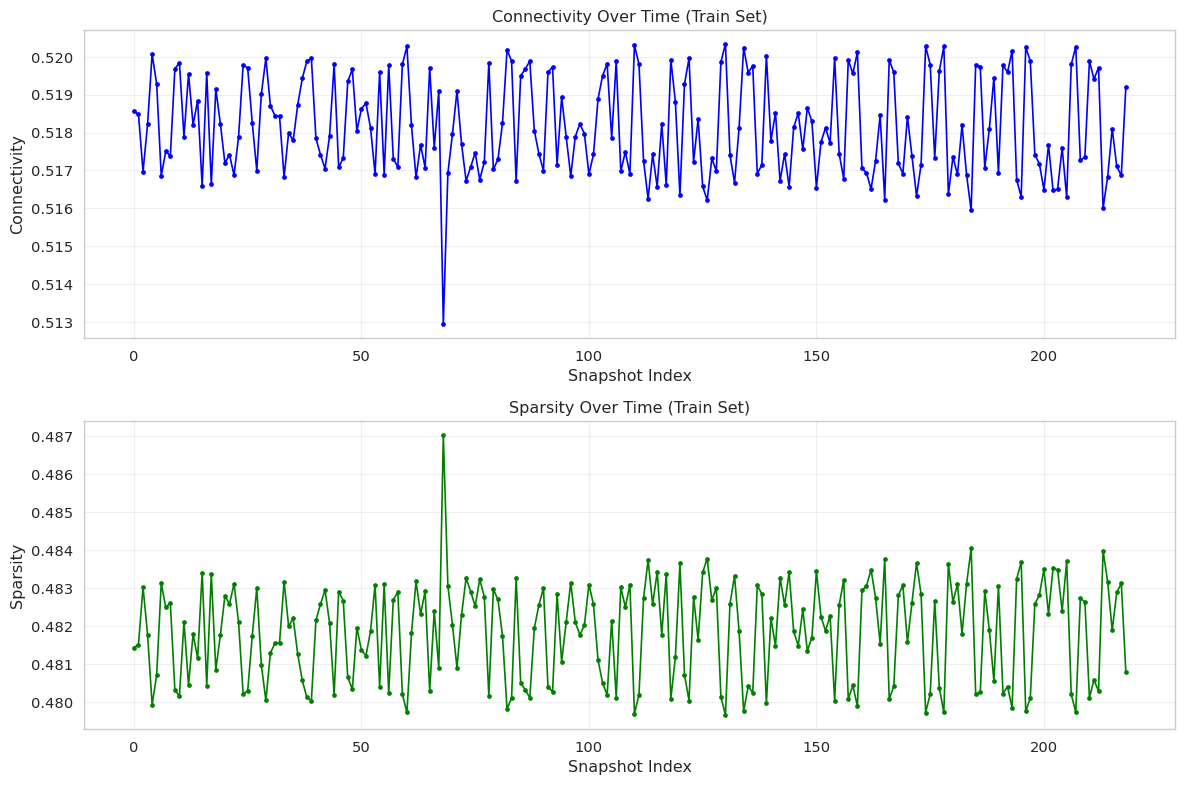

In [38]:
# Graph metrics evolution over time
connectivity_over_time = []
sparsity_over_time = []
for i in range(train_analyzer.num_snapshots):
    snapshot_info = train_analyzer.get_snapshot_info(i)
    connectivity_over_time.append(snapshot_info['connectivity'])
    num_nodes = snapshot_info['num_nodes']
    num_edges = snapshot_info['num_edges']
    possible_edges = num_nodes * (num_nodes - 1)
    sparsity = 1.0 - (num_edges / possible_edges) if possible_edges > 0 else 0.0
    sparsity_over_time.append(sparsity)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(connectivity_over_time, marker='.', linestyle='-', color='blue')
axes[0].set_title('Connectivity Over Time (Train Set)')
axes[0].set_xlabel('Snapshot Index')
axes[0].set_ylabel('Connectivity')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sparsity_over_time, marker='.', linestyle='-', color='green')
axes[1].set_title('Sparsity Over Time (Train Set)')
axes[1].set_xlabel('Snapshot Index')
axes[1].set_ylabel('Sparsity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure('temporal_graph_metrics')
plt.show()

In [ ]:
# Sample up to 500 quadruples per snapshot to keep runtime manageable.
SAMPLE_SIZE = 100
RANDOM_STATE = 42
hyperbolicity_summary = []
hyperbolicity_by_snapshot = []

print("Computing hyperbolicity across datasets...")
for split_name, split_analyzer in analyzers.items():
    print(f"\nProcessing {split_name}...")
    snapshot_scores = []
    for idx in range(split_analyzer.num_snapshots):
        if idx % 10 == 0:
            print(f"  Snapshot {idx}/{split_analyzer.num_snapshots}...", end='\r')
        score = split_analyzer.compute_snapshot_hyperbolicity(idx, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
        snapshot_scores.append(score)
    
    print(f"\n  {split_name} complete: Mean δ = {np.mean(snapshot_scores):.4f}")
    
    if not snapshot_scores:
        continue
    hyperbolicity_summary.append({
        "split": split_name,
        "avg_delta": float(np.mean(snapshot_scores)),
        "std_delta": float(np.std(snapshot_scores)),
        "max_delta": float(np.max(snapshot_scores)),
        "min_delta": float(np.min(snapshot_scores))
    })
    hyperbolicity_by_snapshot.append(pd.DataFrame({
        "split": split_name,
        "snapshot_index": range(len(snapshot_scores)),
        "delta_hyperbolicity": snapshot_scores
    }))

hyperbolicity_summary_df = pd.DataFrame(hyperbolicity_summary).sort_values("avg_delta")
print("\n--- Hyperbolicity Summary (NASDAQ) ---")
display(hyperbolicity_summary_df)

# Save LaTeX table
print("\n--- LaTeX Table: Hyperbolicity Summary ---")
print(hyperbolicity_summary_df.to_latex(caption='Hyperbolicity summary for NASDAQ datasets.',
                                        label='tab:nasdaq_hyperbolicity',
                                        float_format="%.4f",
                                        index=False))

# Plot hyperbolicity over snapshots
hyperbolicity_by_snapshot_df = pd.concat(hyperbolicity_by_snapshot, ignore_index=True) if hyperbolicity_by_snapshot else pd.DataFrame()
if not hyperbolicity_by_snapshot_df.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=hyperbolicity_by_snapshot_df, x="snapshot_index", y="delta_hyperbolicity", 
                 hue="split", marker="o", markersize=4)
    plt.title("δ-Hyperbolicity Over Snapshots (NASDAQ)")
    plt.ylabel("δ-Hyperbolicity")
    plt.xlabel("Snapshot Index")
    plt.legend(title='Dataset')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure('hyperbolicity_across_datasets')
    plt.show()
else:
    print("No hyperbolicity values were computed.")

Computing hyperbolicity across datasets...

Processing Train...


---
## Analysis Complete

All figures have been saved to: `thesis_figures/NYSE/`